# Final Project: Chronic Disease Risk Profiling Using Data Mining
#### **Group:** GR-1
#### **Members:** Sabina Bimbi, Ali Mansouri, Terence Mpofu, Lydia Tembreull
#### **Dataset:** CDC Chronic Disease Indicators (CDI)

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Environment Setup & Data Loading

In [ ]:
# Google Colab drive mount
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running on Google Colab — skipping drive mount.")

Mounted at /content/drive


In [ ]:
# Define possible paths
colab_path = '/content/drive/Othercomputers/My Laptop (1)/CS5831/CS5831-FINAL-PROJECT/U.S._Chronic_Disease_Indicators.csv' # <<< CHANGE THIS TO YOUR FILE PATH
local_path = 'U.S._Chronic_Disease_Indicators.csv'

# Check which one exists and load it
if os.path.exists(colab_path):
    csv_file_path = colab_path
    print("Running on Colab: Using Google Drive path.")
elif os.path.exists(local_path):
    csv_file_path = local_path
    print("Running Locally: Using local folder path.")
else:
    raise FileNotFoundError("Could not find the CSV file in Colab or Local directories.")

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
    display(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Running on Colab: Using Google Drive path.
CSV file loaded successfully!


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(309215, 34)

In [ ]:
df.isnull().sum()

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Question,0
Response,309215
DataValueUnit,0
DataValueType,0


In [ ]:
# Drop columns where all values are missing (empty)
df.dropna(axis = 1, how = 'all', inplace = True)

print("New shape after dropping empty columns:", df.shape)

New shape after dropping empty columns: (309215, 24)


# Data preprocessing

## Option1: Filter based on DataValueType = 'Crude Rate'

In [ ]:
# Filter the dataframe based on DataValueType (option1)
filtered_df = df[(df['DataValueType'] == 'Crude Rate')]

# Pivot the dataframe
# Index: columns to keep as rows
# Columns: convert Topic and Question to columns
# Values: DataValue
pivoted_df = filtered_df.pivot_table(
    index = ['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc'],
    columns = ['Topic', 'Question'],
    values = 'DataValue',
    aggfunc = 'first' # Using 'first' handles any potential duplicate combinations
).reset_index()

# Display the pivoted dataframe
display(pivoted_df.head())
print("Shape of pivoted dataframe:", pivoted_df.shape)

Topic    YearStart YearEnd LocationAbbr LocationDesc  \
Question                                               
0             2015    2019           AK       Alaska   
1             2015    2019           AL      Alabama   
2             2015    2019           AR     Arkansas   
3             2015    2019           AZ      Arizona   
4             2015    2019           CA   California   

Topic                                                               Alcohol  \
Question Chronic liver disease mortality among all people, underlying cause   
0                                                       NaN                   
1                                                       NaN                   
2                                                       NaN                   
3                                                       NaN                   
4                                                       NaN                   

Topic                                                 Asthma  \
Question Asthma mortality among all people, underlying cause   
0                                                       NaN    
1                                                       NaN    
2                                                       NaN    
3                                                       NaN    
4                                                       NaN    

Topic                                                         Cancer  \
Question Breast cancer mortality among all females, underlying cause   
0                                                      17.8            
1                                                      28.1            
2                                                      27.5            
3                                                      10.5            
4                                                      22.8            

Topic                                                                   \
Question Cervical cancer mortality among all females, underlying cause   
0                                                       1.8              
1                                                       3.6              
2                                                       3.8              
3                                                       2.3              
4                                                       3.5              

Topic                                                                                       \
Question Colon and rectum (colorectal) cancer mortality among all people, underlying cause   
0                                                      12.1                                  
1                                                      16.6                                  
2                                                       2.0                                  
3                                                      11.3                                  
4                                                      14.6                                  

Topic                                                                                       \
Question Invasive cancer (all sites combined) mortality among all people, underlying cause   
0                                                      77.6                                  
1                                                      51.3                                  
2                                                      27.2                                  
3                                                     170.8                                  
4                                                     157.2                                  

Topic     ...  \
Question  ...   
0         ...   
1         ...   
2         ...   
3         ...   
4         ...   

Topic                                                           Cardiovascular Disease  \
Question Cerebrovascular disease (stroke) mortality 

Shape of pivoted dataframe: (262, 23)


In [ ]:
pivoted_df.isnull().sum()

Topic                                  Question                                                                                                                        
YearStart                                                                                                                                                                    0
YearEnd                                                                                                                                                                      0
LocationAbbr                                                                                                                                                                 0
LocationDesc                                                                                                                                                                 0
Alcohol                                Chronic liver disease mortality among all people, underlying cause                           

In [ ]:
# Calculate the percentage of null values per column
null_percentage = (pivoted_df.isnull().sum() / len(pivoted_df)) * 100
notnull_count = len(pivoted_df) - pivoted_df.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 54.961832061068705, 46.94656488549619, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 0.0, 0.0, 0.0, 0.0]
[262, 262, 262, 262, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 139, 118, 104, 104, 104, 104, 104, 104, 104]


## Option2: Filter based on DataValueType = 'Crude Prevalence'

In [ ]:
# Filter the dataframe based on DataValueType (option2)
filtered_df = df[(df['DataValueType'] == 'Crude Prevalence')]

# Pivot the dataframe
# Index: columns to keep as rows
# Columns: convert Topic and Question to columns
# Values: DataValue
pivoted_df2 = filtered_df.pivot_table(
    index = ['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc'],
    columns = ['Topic', 'Question'],
    values = 'DataValue',
    aggfunc = 'first' # Using 'first' handles any potential duplicate combinations
).reset_index()

# Display the pivoted dataframe
display(pivoted_df2.head())
print("Shape of pivoted dataframe:", pivoted_df2.shape)

Topic    YearStart YearEnd LocationAbbr LocationDesc  \
Question                                               
0             2018    2019           AK       Alaska   
1             2018    2019           AL      Alabama   
2             2018    2019           AR     Arkansas   
3             2018    2019           AZ      Arizona   
4             2018    2019           CA   California   

Topic                                   Alcohol  \
Question Alcohol use among high school students   
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

Topic                                            \
Question Binge drinking prevalence among adults   
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

Topic                                                          \
Question Binge drinking prevalence among high school students   
0                                                       NaN     
1                                                       NaN     
2                                                       NaN     
3                                                       NaN     
4                                                       NaN     

Topic                                                           Arthritis  \
Question Activity limitation due to arthritis among adults with arthritis   
0                                                       NaN                 
1                                                       NaN                 
2                                                       NaN                 
3                                                       NaN                 
4                                                       NaN                 

Topic                            \
Question Arthritis among adults   
0                           NaN   
1                           NaN   
2                           NaN   
3                           NaN   
4                           NaN   

Topic                                                                                                           \
Question Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis   
0                                                       NaN                                                      
1                                                       NaN                                                      
2                                                       NaN                                                      
3                                                       NaN                                                      
4                                                       NaN                                                      

Topic     ...                       Social Determinants of Health  \
Question  ... No broadband internet subscription among households   
0         ...                                                NaN    
1         ...                                                NaN    
2         ...                                                NaN    
3         ...                                                NaN    
4         ...                                                NaN    

Topic                                                       \
Question Routine checkup within the past year among adults   
0                                                      NaN   
1                                                      NaN   
2                                                      NaN   
3                                                      N

Shape of pivoted dataframe: (476, 85)


## Design Decision

**Option 1 (Crude Rate)** results in 262 rows and 23 disease indicators. **Option 2 (Crude Prevalence)** results in 476 rows and 85 disease indicators. We selected Crude Prevalence (Option 2) as our primary dataset, since it provides a significantly larger features space, which allows for higher model dimensionality. This has the potential to better capture complex relationships between various chronic conditions.

In [ ]:
pivoted_df2.isnull().sum()

Topic         Question                                                             
YearStart                                                                                0
YearEnd                                                                                  0
LocationAbbr                                                                             0
LocationDesc                                                                             0
Alcohol       Alcohol use among high school students                                   382
                                                                                      ... 
Tobacco       Current cigarette smoking among adults                                   261
              Current electronic vapor product use among high school students          383
              Current smokeless tobacco use among high school students                 395
              Current tobacco use of any tobacco product among high school students    399
              Quit attempts in the past year among adult current smokers               325
Length: 85, dtype: int64

In [ ]:
# Calculate the percentage of null values per column
null_percentage = (pivoted_df2.isnull().sum() / len(pivoted_df2)) * 100
notnull_count = len(pivoted_df2) - pivoted_df2.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[92.43697478991596, 92.01680672268907, 92.01680672268907, 92.01680672268907, 89.07563025210085, 88.8655462184874, 88.65546218487394, 88.65546218487394, 86.76470588235294, 86.76470588235294, 84.03361344537815, 83.82352941176471, 83.40336134453781, 83.40336134453781, 82.98319327731093, 82.56302521008404, 81.9327731092437, 81.5126050420168, 81.09243697478992, 80.46218487394958, 80.25210084033614, 80.0420168067227, 80.0420168067227, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 77.73109243697479, 77.73109243697479, 77.73109243697479, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.10084033613445, 77.10084033613445, 77.10084033613445, 77.10084033613445, 77.1008403361344

In [ ]:
print(pivoted_df2.columns.tolist())

[('YearStart', ''), ('YearEnd', ''), ('LocationAbbr', ''), ('LocationDesc', ''), ('Alcohol', 'Alcohol use among high school students'), ('Alcohol', 'Binge drinking prevalence among adults'), ('Alcohol', 'Binge drinking prevalence among high school students'), ('Arthritis', 'Activity limitation due to arthritis among adults with arthritis'), ('Arthritis', 'Arthritis among adults'), ('Arthritis', 'Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis'), ('Arthritis', 'Physical inactivity among adults with arthritis'), ('Arthritis', 'Received health care provider counseling for physical activity among adults with arthritis'), ('Arthritis', 'Severe joint pain among adults with arthritis'), ('Arthritis', 'Work limitation due to arthritis among adults aged 18-64 years with arthritis'), ('Asthma', 'Current asthma among adults'), ('Cancer', 'Cervical cancer screening among women aged 21-65 years'), ('Cancer', 'Colorectal cancer screening among ad

## Rename Columns with Abbreviations

In [ ]:
# --- 1) Define ID-column renaming ---
id_col_map = {
    ('YearStart', ''): 'yr_start',
    ('YearEnd', ''): 'yr_end',
    ('LocationAbbr', ''): 'state_abbr',
    ('LocationDesc', ''): 'state_name'
}

# --- 2) Define topic abbreviations ---
topic_abbr = {
    'Alcohol': 'alc',
    'Arthritis': 'arth',
    'Asthma': 'asth',
    'Cancer': 'can',
    'Cardiovascular Disease': 'cvd',
    'Chronic Obstructive Pulmonary Disease': 'copd',
    'Cognitive Health and Caregiving': 'cog',
    'Diabetes': 'dm',
    'Disability': 'dis',
    'Health Status': 'hs',
    'Immunization': 'imm',
    'Maternal Health': 'mat',
    'Mental Health': 'mh',
    'Nutrition, Physical Activity, and Weight Status': 'npaw',
    'Oral Health': 'oral',
    'Sleep': 'sleep',
    'Social Determinants of Health': 'sdoh',
    'Tobacco': 'tob'
}

# --- 3) Define question abbreviations ---
question_abbr = {
    ('Alcohol', 'Alcohol use among high school students'): 'alcohol_hs',
    ('Alcohol', 'Binge drinking prevalence among adults'): 'binge_adult',
    ('Alcohol', 'Binge drinking prevalence among high school students'): 'binge_hs',

    ('Arthritis', 'Activity limitation due to arthritis among adults with arthritis'): 'activity_limit_arth',
    ('Arthritis', 'Arthritis among adults'): 'arth_adult',
    ('Arthritis', 'Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis'): 'self_mgmt_class_arth',
    ('Arthritis', 'Physical inactivity among adults with arthritis'): 'inactive_arth',
    ('Arthritis', 'Received health care provider counseling for physical activity among adults with arthritis'): 'pa_counsel_arth',
    ('Arthritis', 'Severe joint pain among adults with arthritis'): 'severe_joint_pain_arth',
    ('Arthritis', 'Work limitation due to arthritis among adults aged 18-64 years with arthritis'): 'work_limit_arth_18_64',

    ('Asthma', 'Current asthma among adults'): 'asthma_adult',

    ('Cancer', 'Cervical cancer screening among women aged 21-65 years'): 'screen_cervical_w21_65',
    ('Cancer', 'Colorectal cancer screening among adults aged 45-75 years'): 'screen_colorectal_45_75',
    ('Cancer', 'Mammography use among women aged 50-74 years'): 'mammo_w50_74',

    ('Cardiovascular Disease', 'High blood pressure among adults'): 'hbp_adult',
    ('Cardiovascular Disease', 'High cholesterol among adults who have been screened'): 'high_chol_screened_adult',
    ('Cardiovascular Disease', 'Taking medicine for high cholesterol among adults'): 'med_high_chol_adult',
    ('Cardiovascular Disease', 'Taking medicine to control high blood pressure among adults with high blood pressure'): 'med_hbp_adult',

    ('Chronic Obstructive Pulmonary Disease', 'Chronic obstructive pulmonary disease among adults'): 'copd_adult',
    ('Chronic Obstructive Pulmonary Disease', 'Current smoking among adults with chronic obstructive pulmonary disease'): 'smoking_copd_adult',

    ('Cognitive Health and Caregiving', 'Discussed symptoms of subjective cognitive decline with a health care professional among adults aged 45 years and older with subjective cognitive decline'): 'scd_discussed_hcp_45plus',
    ('Cognitive Health and Caregiving', 'Provided care for a friend or family member in the past month among adults'): 'caregiver_friend_family_adult',
    ('Cognitive Health and Caregiving', 'Provided care for someone with dementia or other cognitive impairment in the past month among adults'): 'caregiver_dementia_adult',
    ('Cognitive Health and Caregiving', 'Subjective cognitive decline among adults aged 45 years and older'): 'scd_45plus',

    ('Diabetes', 'Diabetes among adults'): 'diabetes_adult',
    ('Diabetes', 'Gestational diabetes among women with a recent live birth'): 'gest_diabetes_recent_birth',

    ('Disability', 'Adults with any disability'): 'any_disability_adult',

    ('Health Status', '2 or more chronic conditions among adults'): 'chronic2plus_adult',
    ('Health Status', 'Fair or poor self-rated health status among adults'): 'fair_poor_health_adult',
    ('Health Status', 'Frequent physical distress among adults'): 'phys_distress_freq_adult',

    ('Immunization', 'Influenza vaccination among adults'): 'flu_vax_adult',
    ('Immunization', 'Influenza vaccination among adults 18â€“64 who are at increased risk'): 'flu_vax_risk_18_64',
    ('Immunization', 'Pneumococcal vaccination among adults aged 18â€“64 years who are at increased risk'): 'pneumo_vax_risk_18_64',
    ('Immunization', 'Pneumococcal vaccination among adults aged 65 years and older'): 'pneumo_vax_65plus',

    ('Maternal Health', 'Postpartum checkup among women with a recent live birth'): 'postpartum_check_recent_birth',

    ('Mental Health', 'Current poor mental health among high school students'): 'poor_mh_hs',
    ('Mental Health', 'Depression among adults'): 'depression_adult',
    ('Mental Health', 'Frequent mental distress among adults'): 'mental_distress_freq_adult',
    ('Mental Health', 'Postpartum depressive symptoms among women with a recent live birth'): 'postpartum_depr_recent_birth',

    ('Nutrition, Physical Activity, and Weight Status', 'Children and adolescents aged 6-13 years meeting aerobic physical activity guideline'): 'pa_guideline_6_13',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed fruit less than one time daily among adults'): 'fruit_lt1_daily_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed fruit less than one time daily among high school students'): 'fruit_lt1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed regular soda at least one time daily among high school students'): 'soda_ge1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed vegetables less than one time daily among adults'): 'veg_lt1_daily_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed vegetables less than one time daily among high school students'): 'veg_lt1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Infants who were breastfed at 12 months'): 'breastfed_12m',
    ('Nutrition, Physical Activity, and Weight Status', 'Infants who were exclusively breastfed through 6 months'): 'exclusive_breastfed_6m',
    ('Nutrition, Physical Activity, and Weight Status', 'Met aerobic physical activity guideline among high school students'): 'pa_guideline_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Met aerobic physical activity guideline for substantial health benefits, adults'): 'pa_guideline_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'No leisure-time physical activity among adults'): 'no_leisure_pa_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among WIC children aged 2 to 4 years'): 'obesity_wic_2_4',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among adults'): 'obesity_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among high school students'): 'obesity_hs',

    ('Oral Health', 'All teeth lost among adults aged 65 years and older'): 'all_teeth_lost_65plus',
    ('Oral Health', 'No teeth lost among adults aged 18-64 years'): 'no_teeth_lost_18_64',
    ('Oral Health', 'Preventive dental care in the 12 months before pregnancy among women with a recent live birth'): 'prev_dental_pre_preg_recent_birth',
    ('Oral Health', 'Receipt of evidence-based preventive dental services in the past 12 months among children and adolescents aged 1-17 years'): 'prev_dental_child_1_17',
    ('Oral Health', 'Six or more teeth lost among adults aged 65 years and older'): 'teeth_lost_6plus_65plus',
    ('Oral Health', 'Visited dentist or dental clinic in the past year among adults'): 'dentist_visit_past_year_adult',
    ('Oral Health', 'Visited dentist or other oral health care provider in the past 12 months among children and adolescents aged 1-17 years'): 'dentist_visit_child_1_17',

    ('Sleep', 'Short sleep duration among adults'): 'short_sleep_adult',
    ('Sleep', 'Short sleep duration among children aged 4 months to 14 years'): 'short_sleep_child_4m_14y',
    ('Sleep', 'Short sleep duration among high school students'): 'short_sleep_hs',

    ('Social Determinants of Health', 'Food insecure in the past 12 months among households'): 'food_insecure_household',
    ('Social Determinants of Health', 'Health insurance coverage after pregnancy among women with a recent live birth'): 'ins_after_preg_recent_birth',
    ('Social Determinants of Health', 'Health insurance coverage in the month before pregnancy among women with a recent live birth'): 'ins_before_preg_recent_birth',
    ('Social Determinants of Health', 'High school completion among adults aged 18-24'): 'hs_completion_18_24',
    ('Social Determinants of Health', 'Lack of health insurance among adults aged 18-64 years'): 'no_ins_18_64',
    ('Social Determinants of Health', 'Lack of reliable transportation in the past 12 months among adults'): 'no_transport_adult',
    ('Social Determinants of Health', 'Lack of social and emotional support needed among adults'): 'no_social_emotional_support_adult',
    ('Social Determinants of Health', 'Living below 150% of the poverty threshold among all people'): 'poverty_lt150_all',
    ('Social Determinants of Health', 'No broadband internet subscription among households'): 'no_broadband_household',
    ('Social Determinants of Health', 'Routine checkup within the past year among adults'): 'routine_checkup_adult',
    ('Social Determinants of Health', 'Unable to pay mortgage, rent, or utility bills in the past 12 months among adults'): 'housing_utility_payment_issue_adult',
    ('Social Determinants of Health', 'Unemployment rate among people 16 years and older in the labor force'): 'unemployment_16plus_lf',

    ('Tobacco', 'Cigarette smoking during pregnancy among women with a recent live birth'): 'smoking_preg_recent_birth',
    ('Tobacco', 'Current cigarette smoking among adults'): 'cig_smoking_adult',
    ('Tobacco', 'Current electronic vapor product use among high school students'): 'vape_hs',
    ('Tobacco', 'Current smokeless tobacco use among high school students'): 'smokeless_hs',
    ('Tobacco', 'Current tobacco use of any tobacco product among high school students'): 'any_tobacco_hs',
    ('Tobacco', 'Quit attempts in the past year among adult current smokers'): 'quit_attempt_adult_smokers'
}

# --- 4) Flatten columns and create mapping table ---
new_columns = []
mapping_rows = []

for col in pivoted_df2.columns:
    # If not a tuple, keep as-is
    if not isinstance(col, tuple):
        new_name = col
        orig_topic = ''
        orig_question = ''
    else:
        if col in id_col_map:
            new_name = id_col_map[col]
            orig_topic, orig_question = col
        else:
            topic, question = col
            t_abbr = topic_abbr.get(topic, topic.lower().replace(' ', '_'))
            q_abbr = question_abbr.get((topic, question), question.lower().replace(' ', '_'))
            new_name = f"{t_abbr}__{q_abbr}"
            orig_topic = topic
            orig_question = question

    new_columns.append(new_name)
    mapping_rows.append({
        'new_column': new_name,
        'original_topic': orig_topic,
        'original_question': orig_question
    })

# Apply flattened names
pivoted_df2.columns = new_columns

# Create guideline / dictionary table
col_guideline_df = pd.DataFrame(mapping_rows)

# Optional: sort the guideline table for readability
col_guideline_df = col_guideline_df.sort_values(
    by = ['original_topic', 'original_question', 'new_column'],
    na_position = 'first'
).reset_index(drop = True)

# Show outputs
display(pivoted_df2.head())
display(col_guideline_df)

print("New shape:", pivoted_df2.shape)
print("Example columns:")
print(pivoted_df2.columns.tolist()[:20])

,yr_start,yr_end,state_abbr,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,2018,2019,AK,Alaska,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,2019,AL,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,2019,AR,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,2019,AZ,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,2019,CA,California,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,new_column,original_topic,original_question
0,alc__alcohol_hs,Alcohol,Alcohol use among high school students
1,alc__binge_adult,Alcohol,Binge drinking prevalence among adults
2,alc__binge_hs,Alcohol,Binge drinking prevalence among high school st...
3,arth__activity_limit_arth,Arthritis,Activity limitation due to arthritis among adu...
4,arth__arth_adult,Arthritis,Arthritis among adults
...,...,...,...
80,tob__smokeless_hs,Tobacco,Current smokeless tobacco use among high schoo...
81,tob__any_tobacco_hs,Tobacco,Current tobacco use of any tobacco product amo...
82,tob__quit_attempt_adult_smokers,Tobacco,Quit attempts in the past year among adult cur...
83,yr_end,YearEnd,


New shape: (476, 85)
Example columns:
['yr_start', 'yr_end', 'state_abbr', 'state_name', 'alc__alcohol_hs', 'alc__binge_adult', 'alc__binge_hs', 'arth__activity_limit_arth', 'arth__arth_adult', 'arth__self_mgmt_class_arth', 'arth__inactive_arth', 'arth__pa_counsel_arth', 'arth__severe_joint_pain_arth', 'arth__work_limit_arth_18_64', 'asth__asthma_adult', 'can__screen_cervical_w21_65', 'can__screen_colorectal_45_75', 'can__mammo_w50_74', 'cvd__hbp_adult', 'cvd__high_chol_screened_adult']


In [ ]:
col_guideline_df.to_csv("column_abbreviation_guide.csv", index = False)

In [ ]:
pivoted_df2.to_csv("pivoted_df2.csv", index = False)

## Handle Missing Values & Finalize Cleaning

Imputation of Missing Values

To address missing values in the dataset, we applied a group-wise K-nearest neighbors (KNN) imputation strategy. Since indicator availability varies across time windows, imputation was performed separately for each
(
yr_start
,
yr_end
)
(yr_start,yr_end) group to preserve temporal consistency and avoid mixing information across different years.

Within each time window, we first calculated the proportion of missing values for each indicator. Only indicators with less than 30% missing values were selected for imputation, as higher levels of missingness can lead to unreliable estimates. Indicators exceeding this threshold were excluded from the imputation process for that group.

For the selected indicators, we used a KNN imputer (with
k=5), which replaces missing values based on the average of the nearest neighboring states with similar feature profiles. This approach preserves multivariate relationships between indicators and is more robust than simple mean imputation, especially when data are not missing completely at random.

The imputed values were then written back to the dataset, ensuring that each time window was processed independently. This procedure reduces missingness while maintaining the underlying structure of the data.

In [ ]:
from sklearn.impute import KNNImputer
import numpy as np

# Create a copy to avoid SettingWithCopyWarning
clean_df = pivoted_df2.copy()

# Get indicator columns
indicator_cols = [col for col in clean_df.columns if '__' in col]

# Initialize KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Group by yr_start and yr_end, then apply KNN imputation
for (yr_start, yr_end), group_df in clean_df.groupby(['yr_start', 'yr_end']):

    # Calculate missing percentage for each indicator WITHIN the group
    missing_pct = group_df[indicator_cols].isnull().mean()

    # Identify columns to impute with KNN (< 30% missing in this group)
    knn_cols = missing_pct[missing_pct < 0.3].index.tolist()

    if knn_cols:
        # Fit and transform the group for valid columns
        imputed_values = knn_imputer.fit_transform(group_df[knn_cols])

        # Assign the imputed values back to the main dataframe
        clean_df.loc[group_df.index, knn_cols] = imputed_values


print("Imputation complete. Total missing values remaining:", clean_df[indicator_cols].isnull().sum().sum())

Imputation complete. Total missing values remaining: 27958


In [ ]:
clean_df.to_csv("clean_df.csv", index = False)

## Aggregate indicators across time windows

In [ ]:
clean_df.shape

(476, 85)

In [ ]:
clean_df_alltime = clean_df.groupby(['state_name'])[indicator_cols].mean().reset_index()

print("Aggregated DataFrame shape:", clean_df_alltime.shape)
display(clean_df_alltime.head())

Aggregated DataFrame shape: (55, 82)


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,16.60,71.175000,23.5,6.70,9.466667,16.750,21.20,3.95,25.70,57.450000
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,11.60,69.025000,19.2,6.30,16.700000,20.675,23.24,7.92,30.60,42.150000
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,10.55,71.075000,7.9,5.30,8.300000,15.050,20.75,2.65,23.55,55.850000
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,17.00,68.233333,NaN,4.85,9.766667,14.275,10.95,4.80,19.60,53.833333
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,8.60,68.425000,13.8,6.35,5.330000,11.075,20.21,1.16,21.54,62.100000


In [ ]:
# Calculate the percentage of null values per column
null_percentage = (clean_df_alltime.isnull().sum() / len(clean_df_alltime)) * 100
notnull_count = len(clean_df_alltime) - clean_df_alltime.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[34.54545454545455, 30.909090909090907, 30.909090909090907, 30.909090909090907, 9.090909090909092, 9.090909090909092, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 1.8181818181818181, 1.8181818181818181, 1.8181818181818181, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 54, 54, 54, 52, 52, 52, 52, 52, 52, 52, 50, 50, 38, 38, 

In [ ]:
# Calculate missing percentages for clean_df_alltime
missing_pct_alltime = clean_df_alltime.isnull().mean() * 100

# Identify columns to drop (more than 30% missing)
cols_to_drop = missing_pct_alltime[missing_pct_alltime > 30].index.tolist()

# Drop identified columns
clean_df_alltime_processed = clean_df_alltime.drop(columns=cols_to_drop)

# Identify columns to impute (less than or equal to 30% missing and still have NaNs)
cols_to_impute = clean_df_alltime_processed.columns[clean_df_alltime_processed.isnull().any()].tolist()

# Impute missing values with the mean for the remaining indicator columns
for col in cols_to_impute:
    if '__' in col: # Only impute indicator columns, not 'state_name'
        clean_df_alltime_processed[col] = clean_df_alltime_processed[col].fillna(clean_df_alltime_processed[col].mean())

print(f"Dropped {len(cols_to_drop)} columns with >30% missing values.")
print(f"Imputed remaining missing values in {len(cols_to_impute)} columns with the mean.")
print("Total missing values remaining after processing:", clean_df_alltime_processed.isnull().sum().sum())

display(clean_df_alltime_processed.head())

Dropped 4 columns with >30% missing values.
Imputed remaining missing values in 12 columns with the mean.
Total missing values remaining after processing: 0


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__poverty_lt150_all,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,30.55,16.60,71.175000,6.70,9.466667,16.750,21.20,3.95,25.70,57.450000
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,26.15,11.60,69.025000,6.30,16.700000,20.675,23.24,7.92,30.60,42.150000
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,27.65,10.55,71.075000,5.30,8.300000,15.050,20.75,2.65,23.55,55.850000
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,28.50,17.00,68.233333,4.85,9.766667,14.275,10.95,4.80,19.60,53.833333
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,27.60,8.60,68.425000,6.35,5.330000,11.075,20.21,1.16,21.54,62.100000


In [ ]:
clean_df_alltime_processed.to_csv("clean_df_alltime_processed.csv", index = False)

# Read Clean Data

In [ ]:
# Define possible paths
colab_path = '/content/drive/Othercomputers/My Laptop (1)/CS5831/CS5831-FINAL-PROJECT/clean_df.csv' # <<< CHANGE THIS TO YOUR FILE PATH
local_path = 'U.S._Chronic_Disease_Indicators.csv'

# Check which one exists and load it
if os.path.exists(colab_path):
    csv_file_path = colab_path
    print("Running on Colab: Using Google Drive path.")
elif os.path.exists(local_path):
    csv_file_path = local_path
    print("Running Locally: Using local folder path.")
else:
    raise FileNotFoundError("Could not find the CSV file in Colab or Local directories.")

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
    display(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Running on Colab: Using Google Drive path.
CSV file loaded successfully!


,yr_start,yr_end,state_abbr,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,2018,2019,AK,Alaska,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,2019,AL,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,2019,AR,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,2019,AZ,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,2019,CA,California,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
clean_df =df.copy()
clean_df.describe()

,yr_start,yr_end,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
count,476.000000,476.000000,109.000000,219.000000,109.000000,109.000000,164.000000,109.000000,109.000000,109.000000,...,109.000000,202.000000,38.000000,109.000000,146.000000,219.000000,109.000000,109.000000,92.000000,153.000000
mean,2019.911765,2020.560924,23.560183,16.085753,11.253394,10.512844,27.341463,16.184404,32.397064,66.995780,...,12.283670,74.688119,14.265789,5.771743,6.926301,15.771598,20.173211,4.288991,22.590435,53.925098
std,1.202011,1.069415,7.168258,6.470602,4.711699,4.749317,12.831284,4.376721,7.781213,5.960347,...,3.302076,8.627905,8.081520,2.681578,5.712842,6.081565,7.255828,3.097007,8.638717,7.477555
min,2018.000000,2019.000000,3.700000,3.200000,0.900000,2.000000,5.400000,7.100000,14.700000,47.900000,...,6.600000,55.800000,2.700000,1.200000,0.000000,2.600000,3.500000,0.000000,5.600000,24.800000
25%,2019.000000,2020.000000,19.700000,12.250000,8.300000,6.700000,19.225000,13.300000,27.800000,63.600000,...,9.800000,68.350000,8.575000,3.900000,3.200000,11.400000,16.100000,2.100000,16.900000,49.800000
50%,2020.000000,2021.000000,23.900000,16.000000,11.100000,10.600000,26.650000,15.500000,32.100000,67.600000,...,11.600000,74.450000,12.900000,5.000000,5.850000,15.100000,19.860000,3.400000,21.640000,54.200000
75%,2021.000000,2021.000000,27.760000,20.300000,14.700000,13.400000,33.175000,17.800000,35.800000,70.700000,...,14.600000,80.375000,17.000000,7.300000,9.980000,19.300000,24.300000,5.600000,28.835000,58.300000
max,2022.000000,2022.000000,41.100000,36.100000,24.300000,24.000000,61.500000,33.400000,59.700000,79.400000,...,23.000000,95.800000,46.500000,16.500000,34.700000,37.600000,41.800000,16.200000,50.300000,71.000000


# Target Variable Engineering
### Calculating Burden Score
* Method: Summation of normalized prevalence rates across all 85 predictors
* Threshold: 25th and 75th percentile (0 for <25th, 1 for 25th< <75th and 2 for >75th)

In [ ]:
# Identify indicator columns (from the 5th column, which is index 4)
indicator_cols = [col for col in clean_df.columns[4:] if '__' in col] # Ensure only indicator columns are selected

for col in indicator_cols:
    # Calculate quartiles (Q1 and Q3) for non-null values in the current indicator column
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)

    # Define a function to assign scores based on quartiles
    def assign_score(value):
        if pd.isna(value):  # Preserve null values
            return np.nan
        elif value < q1:
            return 0
        elif q1 <= value < q3:
            return 1
        else:  # value >= q3
            return 2

    # Create a new column for the scores
    clean_df[f'{col}_score'] = clean_df[col].apply(assign_score)

print("Scoring complete. New score columns added to clean_df.")
# Display the head of the DataFrame with new score columns for verification
display(clean_df.head())

Scoring complete. New score columns added to clean_df.


,yr_start,yr_end,state_abbr,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,...,sdoh__no_broadband_household_score,sdoh__routine_checkup_adult_score,sdoh__housing_utility_payment_issue_adult_score,sdoh__unemployment_16plus_lf_score,tob__smoking_preg_recent_birth_score,tob__cig_smoking_adult_score,tob__vape_hs_score,tob__smokeless_hs_score,tob__any_tobacco_hs_score,tob__quit_attempt_adult_smokers_score
0,2018,2019,AK,Alaska,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,2019,AL,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,2019,AR,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,2019,AZ,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,2019,CA,California,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
indicator_cols = [col for col in clean_df.columns[4:] if '__' in col]
clean_df_alltime = clean_df.groupby(['state_name'])[indicator_cols].mean().reset_index()

print("Aggregated DataFrame shape:", clean_df_alltime.shape)
display(clean_df_alltime.head())

Aggregated DataFrame shape: (55, 163)


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__no_broadband_household_score,sdoh__routine_checkup_adult_score,sdoh__housing_utility_payment_issue_adult_score,sdoh__unemployment_16plus_lf_score,tob__smoking_preg_recent_birth_score,tob__cig_smoking_adult_score,tob__vape_hs_score,tob__smokeless_hs_score,tob__any_tobacco_hs_score,tob__quit_attempt_adult_smokers_score
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,2.0,0.750000,2.0,1.5,1.666667,1.25,1.0,1.0,1.5,1.5
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,0.5,0.750000,2.0,1.0,1.500000,1.50,1.5,1.5,2.0,1.0
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,0.5,0.500000,0.0,1.0,1.500000,1.00,1.5,0.5,1.0,1.5
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,1.5,0.666667,NaN,1.0,1.666667,1.00,0.5,1.5,0.5,1.0
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,0.5,0.250000,1.0,1.5,1.000000,0.25,1.0,0.5,1.0,1.5


In [ ]:
# Calculate missing percentages for clean_df_alltime
missing_pct_alltime = clean_df_alltime.isnull().mean() * 100

# Identify columns to drop (more than 30% missing)
cols_to_drop = missing_pct_alltime[missing_pct_alltime > 30].index.tolist()

# Drop identified columns
clean_df_alltime_processed = clean_df_alltime.drop(columns=cols_to_drop)

# Identify columns to impute (less than or equal to 30% missing and still have NaNs)
cols_to_impute = clean_df_alltime_processed.columns[clean_df_alltime_processed.isnull().any()].tolist()

# Impute missing values with the mean for the remaining indicator columns
for col in cols_to_impute:
    if '__' in col: # Only impute indicator columns, not 'state_name'
        clean_df_alltime_processed[col] = clean_df_alltime_processed[col].fillna(clean_df_alltime_processed[col].mean())

print(f"Dropped {len(cols_to_drop)} columns with >30% missing values.")
print(f"Imputed remaining missing values in {len(cols_to_impute)} columns with the mean.")
print("Total missing values remaining after processing:", clean_df_alltime_processed.isnull().sum().sum())

display(clean_df_alltime_processed.head())

Dropped 8 columns with >30% missing values.
Imputed remaining missing values in 24 columns with the mean.
Total missing values remaining after processing: 0


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__poverty_lt150_all_score,sdoh__no_broadband_household_score,sdoh__routine_checkup_adult_score,sdoh__unemployment_16plus_lf_score,tob__smoking_preg_recent_birth_score,tob__cig_smoking_adult_score,tob__vape_hs_score,tob__smokeless_hs_score,tob__any_tobacco_hs_score,tob__quit_attempt_adult_smokers_score
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,1.5,2.0,0.750000,1.5,1.666667,1.25,1.0,1.0,1.5,1.5
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,1.0,0.5,0.750000,1.0,1.500000,1.50,1.5,1.5,2.0,1.0
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,1.5,0.5,0.500000,1.0,1.500000,1.00,1.5,0.5,1.0,1.5
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,2.0,1.5,0.666667,1.0,1.666667,1.00,0.5,1.5,0.5,1.0
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,1.5,0.5,0.250000,1.5,1.000000,0.25,1.0,0.5,1.0,1.5


In [ ]:
# Identify all columns ending with '_score'
score_cols = [col for col in clean_df_alltime_processed.columns if col.endswith('_score')]

# Calculate the sum of these score columns for each row
clean_df_alltime_processed['total_score'] = clean_df_alltime_processed[score_cols].sum(axis=1)

# Calculate quartiles for the new 'total_score' column
total_score_q1 = clean_df_alltime_processed['total_score'].quantile(0.25)
total_score_q3 = clean_df_alltime_processed['total_score'].quantile(0.75)

# Define a function to assign scores based on quartiles for the 'total_score'
def assign_total_score_risk_level(value):
    if value < total_score_q1:
        return 0
    elif total_score_q1 <= value < total_score_q3:
        return 1
    else:  # value >= total_score_q3
        return 2

# Create a new column for the risk level of the total score
clean_df_alltime_processed['total_score_risk_level'] = clean_df_alltime_processed['total_score'].apply(assign_total_score_risk_level)

print("New 'total_score' and 'total_score_risk_level' columns added.")
display(clean_df_alltime_processed.head())

New 'total_score' and 'total_score_risk_level' columns added.


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__routine_checkup_adult_score,sdoh__unemployment_16plus_lf_score,tob__smoking_preg_recent_birth_score,tob__cig_smoking_adult_score,tob__vape_hs_score,tob__smokeless_hs_score,tob__any_tobacco_hs_score,tob__quit_attempt_adult_smokers_score,total_score,total_score_risk_level
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,0.750000,1.5,1.666667,1.25,1.0,1.0,1.5,1.5,92.500000,2
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,0.750000,1.0,1.500000,1.50,1.5,1.5,2.0,1.0,69.666667,0
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,0.500000,1.0,1.500000,1.00,1.5,0.5,1.0,1.5,71.250000,1
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,0.666667,1.0,1.666667,1.00,0.5,1.5,0.5,1.0,94.916667,2
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,0.250000,1.5,1.000000,0.25,1.0,0.5,1.0,1.5,70.083333,0


In [ ]:
# Identify original indicator columns (those without '_score')
original_indicator_cols = [col for col in clean_df_alltime_processed.columns if '__' in col and not col.endswith('_score')]

# Define columns to keep
columns_to_keep = ['state_name'] + original_indicator_cols + ['total_score_risk_level']

# Filter the DataFrame to keep only the specified columns
clean_df_alltime_final = clean_df_alltime_processed[columns_to_keep].copy()

print("DataFrame after dropping columns:")
display(clean_df_alltime_final.head())
print(f"New shape: {clean_df_alltime_final.shape}")

DataFrame after dropping columns:


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers,total_score_risk_level
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,16.60,71.175000,6.70,9.466667,16.750,21.20,3.95,25.70,57.450000,2
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,11.60,69.025000,6.30,16.700000,20.675,23.24,7.92,30.60,42.150000,0
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,10.55,71.075000,5.30,8.300000,15.050,20.75,2.65,23.55,55.850000,1
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,17.00,68.233333,4.85,9.766667,14.275,10.95,4.80,19.60,53.833333,2
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,8.60,68.425000,6.35,5.330000,11.075,20.21,1.16,21.54,62.100000,0


New shape: (55, 79)


In [ ]:
clean_df_alltime_final.to_csv("clean_df_alltime_final.csv", index = False)

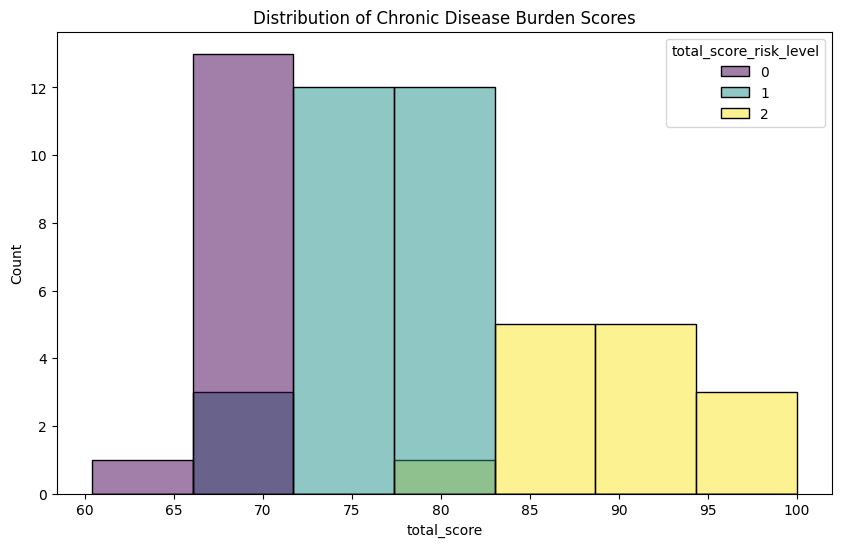

In [ ]:
plt.figure(figsize = (10, 6))
sns.histplot(data = clean_df_alltime_processed, x = 'total_score', hue = 'total_score_risk_level', kde = False, palette = 'viridis')
plt.title('Distribution of Chronic Disease Burden Scores')
plt.show()

In [ ]:
# See which State/Year has the absolute highest burden
cols_to_show = ['state_name', 'total_score']

print(clean_df_alltime_processed[cols_to_show]
      .sort_values(by = 'total_score', ascending = False)
      .head(10))

       state_name  total_score
52  West Virginia   100.000000
44      Tennessee    98.250000
3        Arkansas    94.916667
19      Louisiana    94.083333
18       Kentucky    92.583333
0         Alabama    92.500000
32     New Mexico    92.166667
25    Mississippi    91.750000
36           Ohio    87.750000
26       Missouri    86.750000


### Correlation Analysis to See Which Indicators are Pushing States into the High-Risk Category

In [ ]:
# Calculate correlation of all indicators with the burden score
correlations = clean_df_alltime_final.corr(numeric_only = True)['total_score_risk_level'].sort_values(ascending = False)

# Look at top 10 strongest drivers of chronic disease risk
print('Top Drivers of High-Risk Scores:')
print(correlations.head(11))

Top Drivers of High-Risk Scores:
total_score_risk_level             1.000000
arth__activity_limit_arth          0.719467
sdoh__no_broadband_household       0.668804
oral__all_teeth_lost_65plus        0.635886
sdoh__food_insecure_household      0.597707
arth__work_limit_arth_18_64        0.567049
copd__smoking_copd_adult           0.562347
hs__chronic2plus_adult             0.533253
sleep__short_sleep_child_4m_14y    0.525205
npaw__soda_ge1_daily_hs            0.514763
npaw__obesity_adult                0.504816
Name: total_score_risk_level, dtype: float64


### total_score_risk_level Map plot

US states shapefile loaded successfully.


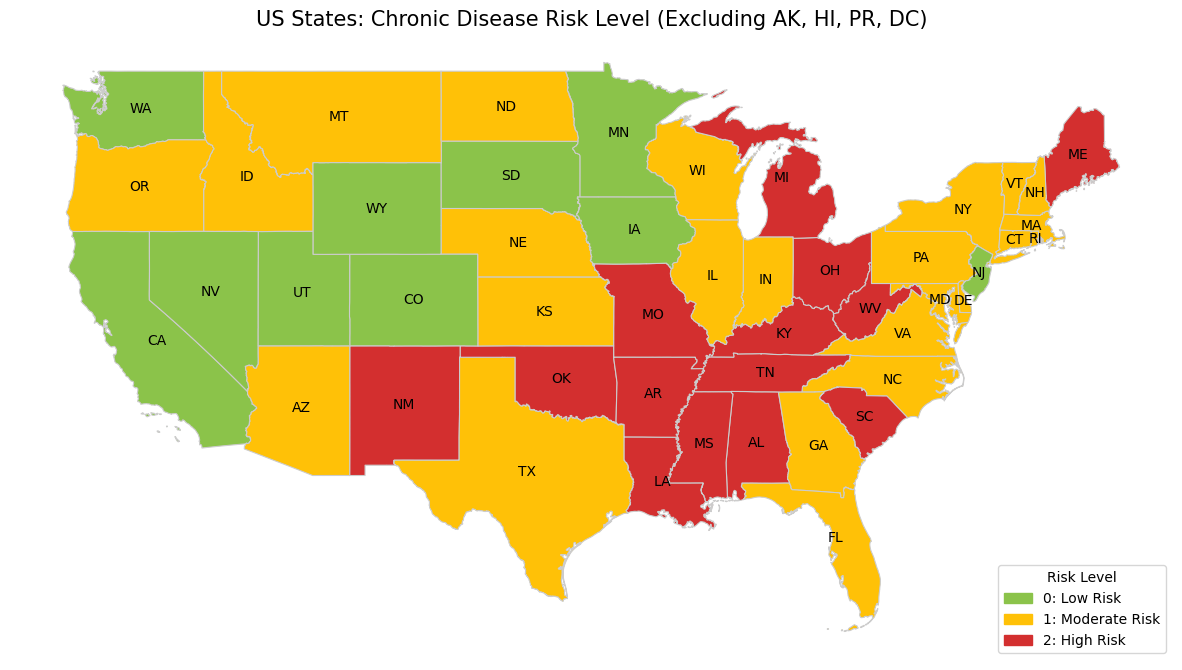

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches # Import for custom legend

# Load US states shapefile from a publicly available source (Census Bureau)
# Using 5m resolution for reasonable detail
try:
    # This URL provides a shapefile for US states
    states_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_5m.zip")
    print("US states shapefile loaded successfully.")
except Exception as e:
    print(f"Error loading states shapefile. Please ensure 'geopandas' is installed and the URL is accessible: {e}")
    print("You might need to install geopandas: !pip install geopandas")
    raise

# Rename 'NAME' column in states_gdf to 'state_name' to match clean_df_alltime_final
states_gdf = states_gdf.rename(columns={'NAME': 'state_name'})

# Filter out non-contiguous states/territories
states_to_exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'District of Columbia', 'Guam', 'Virgin Islands']
states_gdf = states_gdf[~states_gdf['state_name'].isin(states_to_exclude)]

# Create a state_name to state_abbr mapping from clean_df
state_abbr_map = clean_df[['state_name', 'state_abbr']].drop_duplicates().set_index('state_name')['state_abbr'].to_dict()

# Merge clean_df_alltime_final with the GeoDataFrame
# Using an inner merge to only plot states for which we have data
merged_gdf = states_gdf.merge(clean_df_alltime_final, on='state_name', how='inner')

# Add state abbreviations to merged_gdf
merged_gdf['state_abbr'] = merged_gdf['state_name'].map(state_abbr_map)

# Define custom discrete colormap for risk levels
# 0: Low Risk (Green), 1: Medium Risk (Orange), 2: High Risk (Red)
cmap_colors = ['#8BC34A', '#FFC107', '#D32F2F'] # Green, Amber, Red
cust_cmap = ListedColormap(cmap_colors)

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the states, color-coded by 'total_score_risk_level'
# Removed `legend=True` to prevent the default continuous colorbar
merged_gdf.plot(column='total_score_risk_level',
                cmap=cust_cmap,
                linewidth=0.8,
                ax=ax,
                edgecolor='0.8')

# Create custom legend handles
legend_patches = [
    mpatches.Patch(color=cmap_colors[0], label='0: Low Risk'),
    mpatches.Patch(color=cmap_colors[1], label='1: Moderate Risk'),
    mpatches.Patch(color=cmap_colors[2], label='2: High Risk')
]

# Add the custom legend to the plot
ax.legend(handles=legend_patches, title='Risk Level', loc='lower right', frameon=True)

# Add state labels (abbreviations)
# Adjust fontsize and color as needed for readability
for x, y, label in zip(merged_gdf.geometry.centroid.x, merged_gdf.geometry.centroid.y, merged_gdf['state_abbr']):
    ax.text(x, y, label, fontsize=10, ha='center', va='center', color='black') # Increased fontsize to 10

# Set a plain background
ax.set_facecolor('white')

# Remove axis ticks and labels
ax.set_axis_off()

plt.title('US States: Chronic Disease Risk Level (Excluding AK, HI, PR, DC)', fontsize=15)
plt.show()

# Dataset Preparation & Splitting

In [ ]:
X = clean_df_alltime_final.filter(like = '__') # grabs all diesease indicators
y = clean_df_alltime_final['total_score_risk_level']

A stratified split was used to ensure the model learns from a balanced representation of high-risk and low-risk cases.

In [ ]:
scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

# Supervised Classification
### Models: Logistic Regression, Random Forest
We compare two simple classifiers (because of small number of rows) to predict whether a state-year observation falls into which risk chronic disease category. Each model is evaluated using stratified 5-fold cross-validation and a held-out test set. Metrics reported include accuracy, precision, recall, F1-score, and ROC-AUC.

### Feature Scaling
Logistic Regression requires scaled features. We apply StandardScaler to X_train and X_test before model training.


### Stratified 5-Fold Cross-Validation
A helper function runs stratified 5-fold CV on each model and returns mean ± std for all key metrics. Results are then reported on the held-out test set.

In [ ]:
def evaluate_model_cv(model, X, y, model_name="Model"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    print(f"\n{'='*50}")
    print(f"  {model_name} — 5-Fold CV Results")
    print(f"{'='*50}")
    for metric in scoring:
        scores = results[f'test_{metric}']
        print(f"  {metric.capitalize():12s}: {scores.mean():.4f} ± {scores.std():.4f}")
    return results

### Model 1: Logistic Regression
Serves as the interpretable baseline using L2 regularization.

### Model 2: Random Forest
An ensemble of decision trees using bagging. Handles non-linearity well and provides feature importance scores.

In [ ]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_cv = evaluate_model_cv(lr, X_scaled, y, "Logistic Regression")


lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X, y)

overall_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_coef': np.mean(np.abs(lr_pipe.named_steps['clf'].coef_), axis=0)
}).sort_values('mean_abs_coef', ascending=False)

display(overall_importance.head(10))


  Logistic Regression — 5-Fold CV Results
  Accuracy    : 0.6727 ± 0.0727
  Precision_macro: 0.7002 ± 0.0945
  Recall_macro: 0.6556 ± 0.0579
  F1_macro    : 0.6617 ± 0.0690
  Roc_auc_ovr : 0.8819 ± 0.0291


,feature,mean_abs_coef
13,can__mammo_w50_74,0.287079
76,tob__quit_attempt_adult_smokers,0.273902
26,dis__any_disability_adult,0.265611
52,oral__all_teeth_lost_65plus,0.263635
3,arth__activity_limit_arth,0.259879
20,cog__scd_discussed_hcp_45plus,0.256672
69,sdoh__routine_checkup_adult,0.249057
9,arth__work_limit_arth_18_64,0.236975
14,cvd__hbp_adult,0.222624
67,sdoh__poverty_lt150_all,0.214189


In [ ]:
# Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_cv = evaluate_model_cv(rf, X, y, "Random Forest")

rf.fit(X, y)

rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_importance.head(10))


  Random Forest — 5-Fold CV Results
  Accuracy    : 0.6545 ± 0.1564
  Precision_macro: 0.5462 ± 0.2207
  Recall_macro: 0.5733 ± 0.1594
  F1_macro    : 0.5353 ± 0.1849
  Roc_auc_ovr : 0.8553 ± 0.0962


,feature,importance
68,sdoh__no_broadband_household,0.058411
3,arth__activity_limit_arth,0.057226
62,sdoh__food_insecure_household,0.053726
13,can__mammo_w50_74,0.036253
19,copd__smoking_copd_adult,0.028068
72,tob__cig_smoking_adult,0.026940
20,cog__scd_discussed_hcp_45plus,0.026252
26,dis__any_disability_adult,0.024005
24,dm__diabetes_adult,0.023897
52,oral__all_teeth_lost_65plus,0.023318


# Unsupervised Clustering
### Methods: K-Means and DBSCAN
Clustering is applied to the full scaled feature matrix to identify natural groupings of state-year observations based on chronic disease and behavioral profiles; independent of the risk labels. Internal validation uses Silhouette Score and Davies-Bouldin Index. Clusters are visualized via PCA 2D projection and profiled by their top indicator patterns.

### K-Means Clustering
The Elbow Method and Silhouette Score are used to select the optimal number of clusters k, then the final model is fit and evaluated.

Running K-Means for each year pair (without PCA):


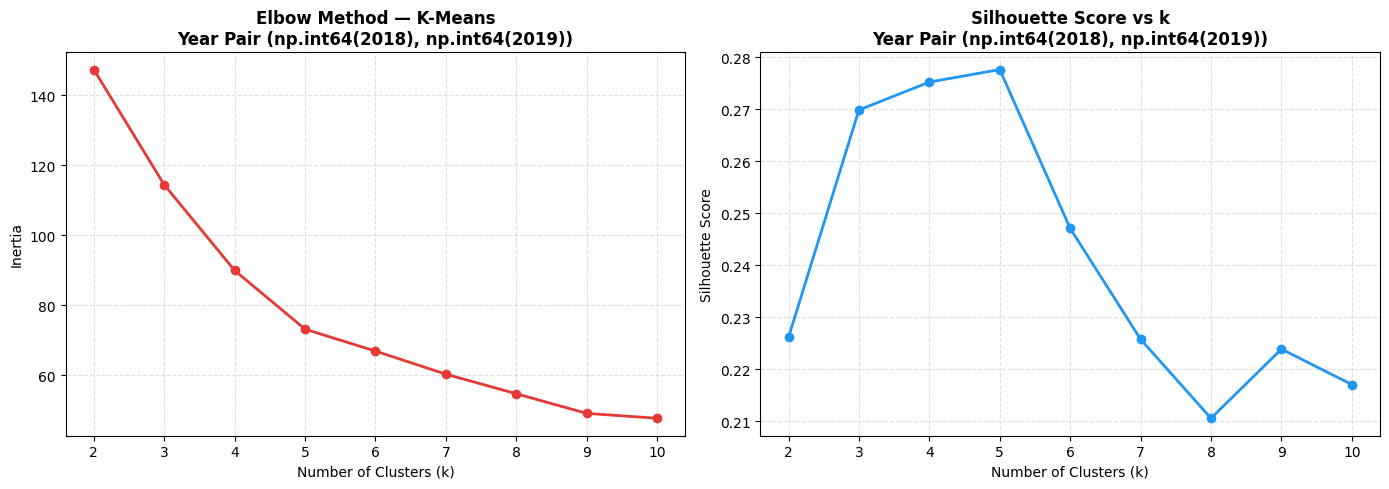

Year Pair (np.int64(2018), np.int64(2019)) | Optimal k: 5
K-Means | Silhouette: 0.2776 | Davies-Bouldin: 1.0435
------------------------------------------------------------


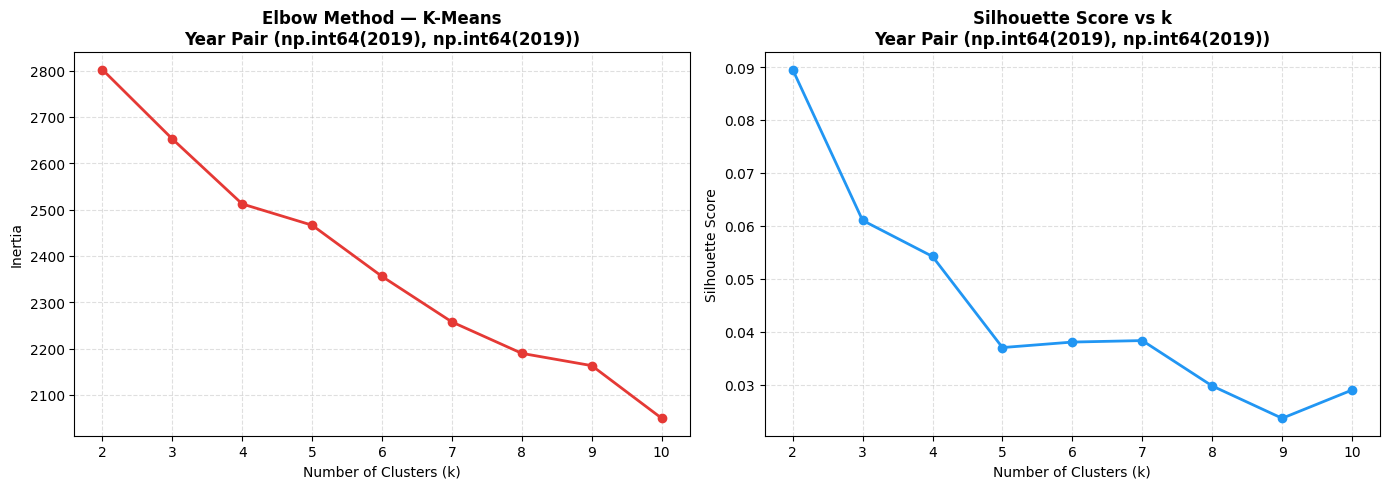

Year Pair (np.int64(2019), np.int64(2019)) | Optimal k: 2
K-Means | Silhouette: 0.0895 | Davies-Bouldin: 2.7086
------------------------------------------------------------


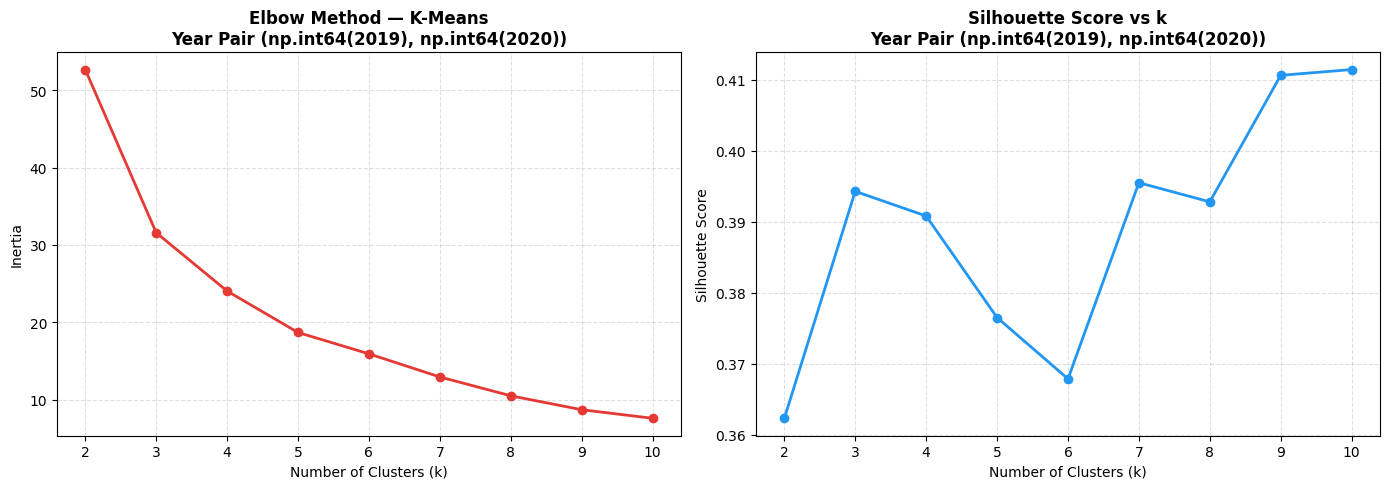

Year Pair (np.int64(2019), np.int64(2020)) | Optimal k: 10
K-Means | Silhouette: 0.4114 | Davies-Bouldin: 0.6068
------------------------------------------------------------


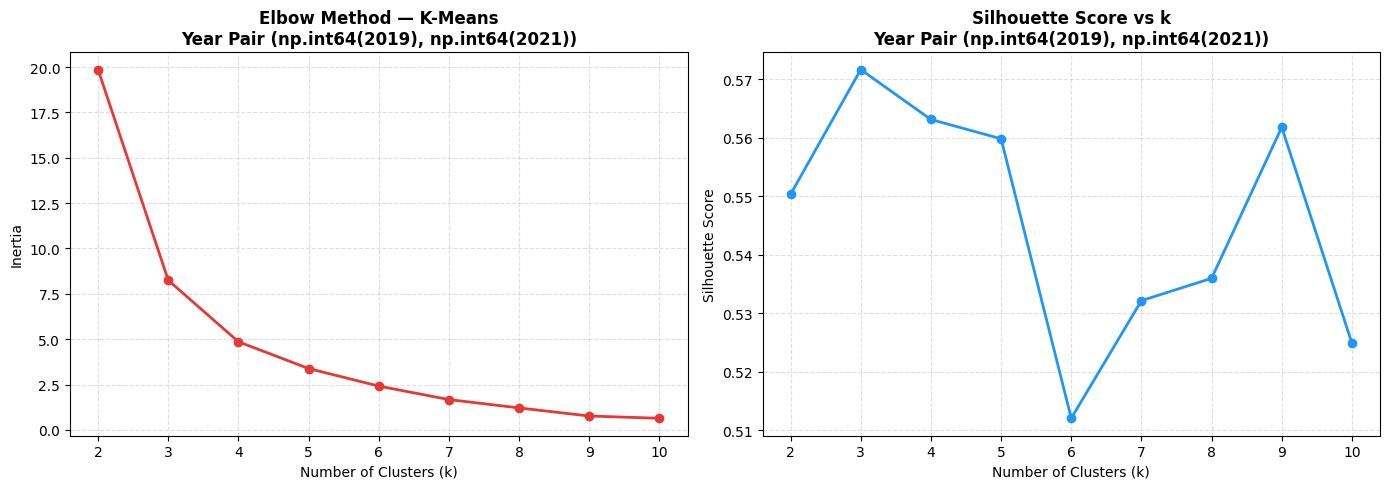

Year Pair (np.int64(2019), np.int64(2021)) | Optimal k: 3
K-Means | Silhouette: 0.5717 | Davies-Bouldin: 0.4907
------------------------------------------------------------


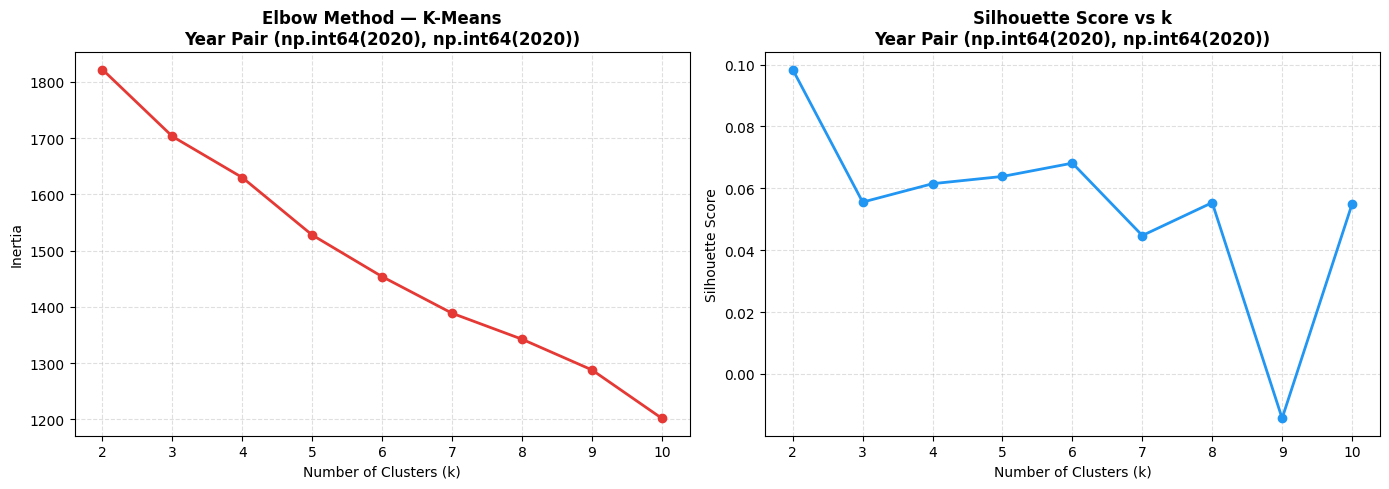

Year Pair (np.int64(2020), np.int64(2020)) | Optimal k: 2
K-Means | Silhouette: 0.0984 | Davies-Bouldin: 2.8142
------------------------------------------------------------


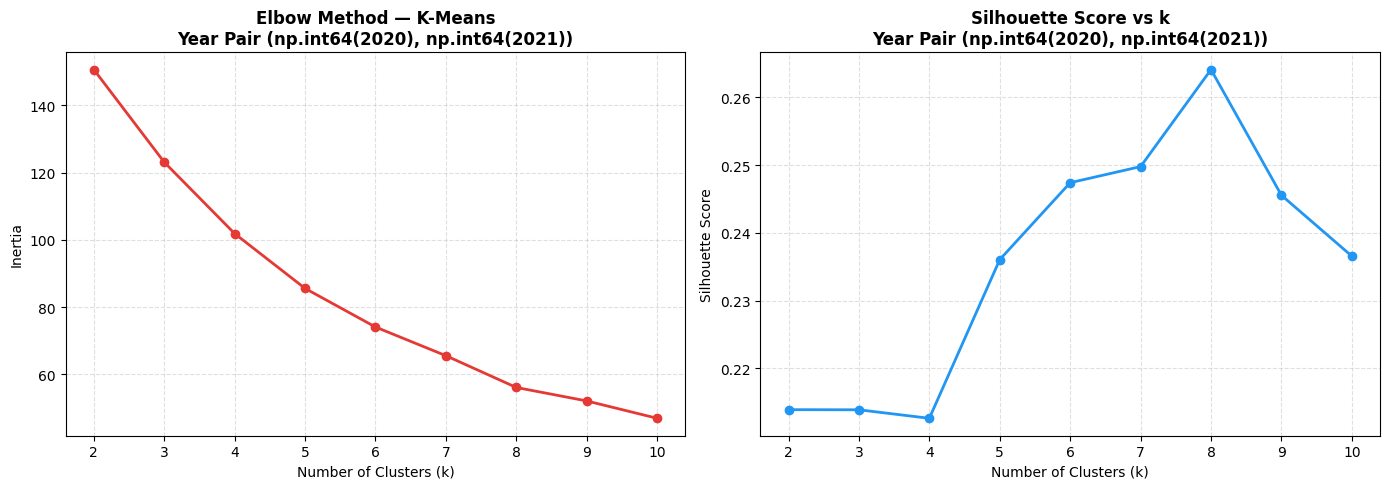

Year Pair (np.int64(2020), np.int64(2021)) | Optimal k: 8
K-Means | Silhouette: 0.2641 | Davies-Bouldin: 1.0195
------------------------------------------------------------


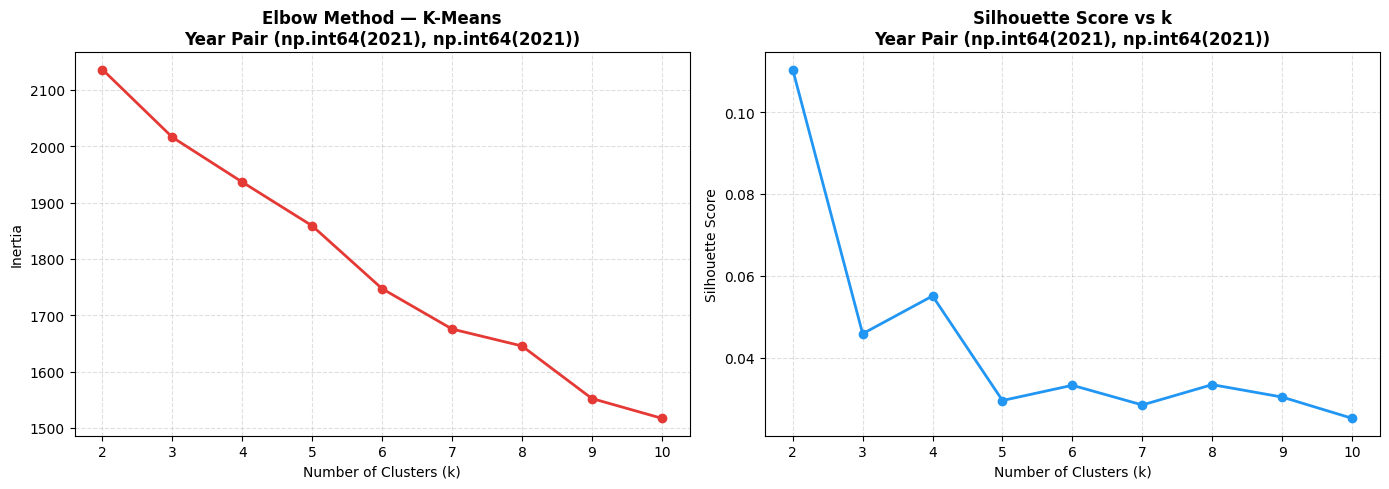

Year Pair (np.int64(2021), np.int64(2021)) | Optimal k: 2
K-Means | Silhouette: 0.1104 | Davies-Bouldin: 2.7790
------------------------------------------------------------


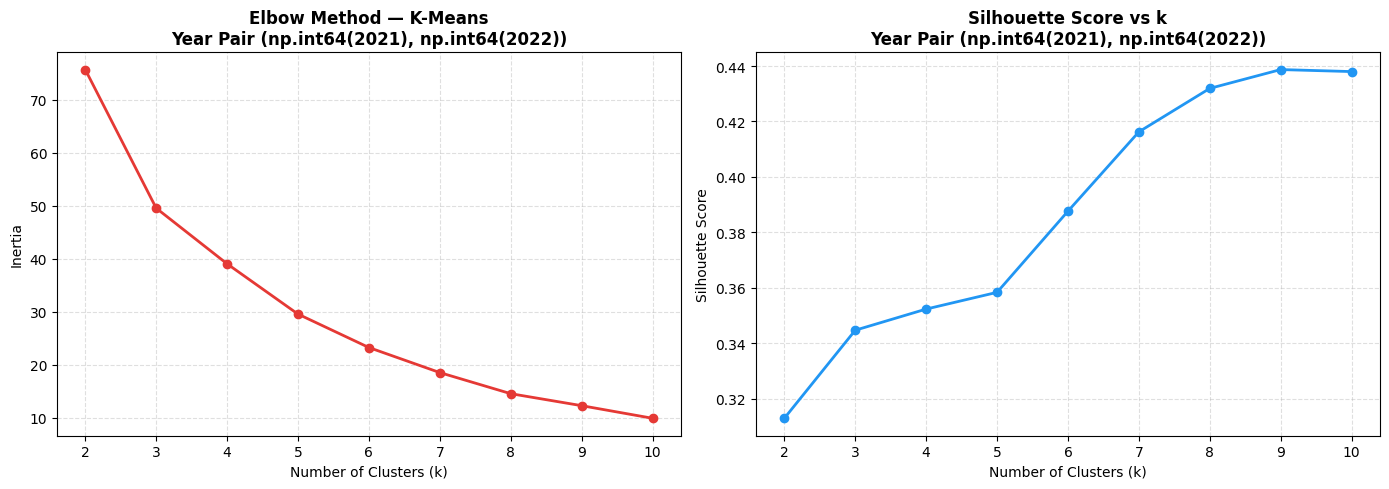

Year Pair (np.int64(2021), np.int64(2022)) | Optimal k: 9
K-Means | Silhouette: 0.4387 | Davies-Bouldin: 0.6269
------------------------------------------------------------


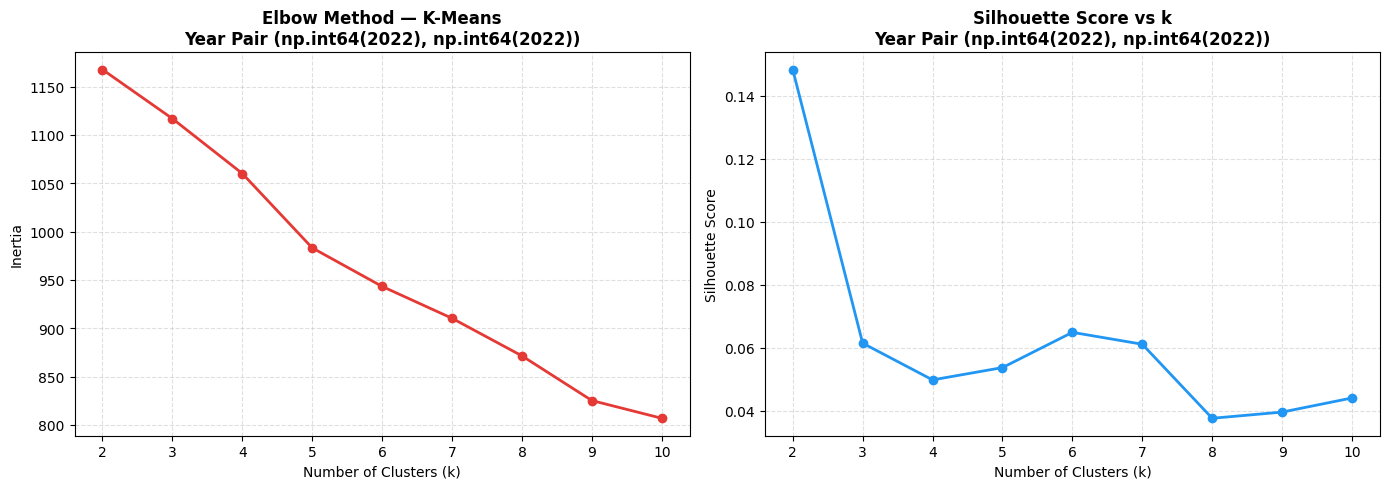

Year Pair (np.int64(2022), np.int64(2022)) | Optimal k: 2
K-Means | Silhouette: 0.1483 | Davies-Bouldin: 2.3773
------------------------------------------------------------


In [ ]:
# Dictionaries to store clustering outputs for each year pair
all_inertias = {}
all_sil_scores = {}
all_best_k = {}
all_kmeans_labels = {}
all_kmeans_models = {}
all_kmeans_metrics = {}

print("Running K-Means for each year pair (without PCA):")

# Prepare global scaled data once
X_original_indicators = clean_df.filter(like = '__')
scaler_kmeans = StandardScaler() # Use a new scaler to avoid conflict with supervised learning scaler
X_scaled = scaler_kmeans.fit_transform(X_original_indicators)
# Create a DataFrame from scaled data to easily subset by index later
X_scaled_df = pd.DataFrame(X_scaled, index=clean_df.index, columns=X_original_indicators.columns)


# Collect unique year pairs from the original clean_df
unique_year_pairs = clean_df[['yr_start', 'yr_end']].drop_duplicates().values

for yr_start_val, yr_end_val in unique_year_pairs:
    year_pair = (yr_start_val, yr_end_val) # Create the key for dictionaries

    # Get the indices for the current year pair in clean_df
    current_year_indices = clean_df[
        (clean_df['yr_start'] == yr_start_val) &
        (clean_df['yr_end'] == yr_end_val)
    ].index

    # Get the scaled indicator data for this specific year pair
    X_all_year_pair = X_scaled_df.loc[current_year_indices].dropna(axis=1) # Drop columns with NaNs if any, for robustness
    X_all = X_all_year_pair.values # Convert to numpy array for clustering algorithms

    n_samples = X_all.shape[0]

    # Need at least 3 samples for clustering with k >= 2
    if n_samples < 3:
        print(f"Year Pair {year_pair}: Not enough samples for clustering (n={n_samples}). Skipping.")
        continue

    # Adaptive k range
    # Ensure n_samples - 1 is positive before min
    max_k_candidate = n_samples - 1
    if max_k_candidate < 1: # if n_samples is 1 or 2, then n_samples-1 is 0 or 1
        max_k = 1 # We'll check if max_k < 2 below
    else:
        max_k = min(10, max_k_candidate)

    if max_k < 2: # No meaningful clustering if max_k is 0 or 1
        print(f"Year Pair {year_pair}: max_k < 2 (n_samples={n_samples}). Skipping.")
        continue

    k_range = range(2, max_k + 1)
    inertias = []
    sil_scores = []

    # Compute clustering metrics across k
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_all)

        inertias.append(km.inertia_)

        # silhouette requires at least 2 clusters and fewer clusters than samples
        if len(np.unique(labels)) > 1 and len(np.unique(labels)) < n_samples:
            sil_scores.append(silhouette_score(X_all, labels))
        else:
            sil_scores.append(np.nan)

    # Store curves
    all_inertias[year_pair] = inertias
    all_sil_scores[year_pair] = sil_scores

    # Plot for this year pair
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(k_range, inertias, marker='o', color='#E53935', linewidth=2)
    axes[0].set_title(f'Elbow Method — K-Means\nYear Pair {year_pair}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(k_range, sil_scores, marker='o', color='#2196F3', linewidth=2)
    axes[1].set_title(f'Silhouette Score vs k\nYear Pair {year_pair}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # Choose best k based on silhouette
    valid_sil = [s for s in sil_scores if not np.isnan(s)]
    if len(valid_sil) == 0:
        print(f"Year Pair {year_pair}: No valid silhouette scores. Skipping final K-Means.")
        continue

    # Need to check if k_range is empty if max_k < 2 initially
    if not k_range:
        print(f"Year Pair {year_pair}: k_range is empty. Skipping final K-Means.")
        continue

    best_idx = int(np.nanargmax(sil_scores))
    best_k = list(k_range)[best_idx]
    all_best_k[year_pair] = best_k

    # Final KMeans for this year pair
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    km_sil = silhouette_score(X_all, km_labels)
    km_db = davies_bouldin_score(X_all, km_labels)

    all_kmeans_labels[year_pair] = km_labels
    all_kmeans_models[year_pair] = km_final
    all_kmeans_metrics[year_pair] = {
        'best_k': best_k,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"Year Pair {year_pair} | Optimal k: {best_k}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)

In [ ]:
# Dictionaries to store clustering outputs for each year pair
all_best_k = {}
all_kmeans_labels = {}
all_kmeans_models = {}
all_kmeans_metrics = {}

# Set your desired manual K value here
# For example, manual_k = 3, manual_k = 5, etc.
manual_k_value = 3 # You can change this value as needed

print(f"Running K-Means for each year pair with manual k = {manual_k_value} (without PCA):")

# Prepare global scaled data once, similar to cell mdynCIovZROq
X_original_indicators = clean_df.filter(like = '__')
scaler_kmeans = StandardScaler()
X_scaled_all = scaler_kmeans.fit_transform(X_original_indicators)
X_scaled_df = pd.DataFrame(X_scaled_all, index=clean_df.index, columns=X_original_indicators.columns)

# Collect unique year pairs from the original clean_df
unique_year_pairs = clean_df[['yr_start', 'yr_end']].drop_duplicates().values

for yr_start_val, yr_end_val in unique_year_pairs:
    year_pair = (yr_start_val, yr_end_val) # Create the key for dictionaries

    # Get the indices for the current year pair in clean_df
    current_year_indices = clean_df[
        (clean_df['yr_start'] == yr_start_val) &
        (clean_df['yr_end'] == yr_end_val)
    ].index

    # Get the scaled indicator data for this specific year pair
    X_all_year_pair = X_scaled_df.loc[current_year_indices].dropna(axis=1) # Drop columns with NaNs if any, for robustness
    X_all = X_all_year_pair.values # Convert to numpy array for clustering algorithms

    n_samples = X_all.shape[0]

    # Need at least 'manual_k_value' samples for clustering
    if n_samples < manual_k_value:
        print(f"Year Pair {year_pair}: Not enough samples for clustering with k={manual_k_value} (n={n_samples}). Skipping.")
        continue

    # Also ensure k is valid for the number of samples
    if manual_k_value < 2 or manual_k_value > n_samples -1:
        print(f"Year Pair {year_pair}: Invalid k value {manual_k_value} for {n_samples} samples. Skipping.")
        continue

    # K-Means with the manual K value
    km_final = KMeans(n_clusters=manual_k_value, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    # Evaluate the clustering
    # silhouette requires at least 2 clusters and fewer clusters than samples
    if len(np.unique(km_labels)) > 1 and len(np.unique(km_labels)) < n_samples:
        km_sil = silhouette_score(X_all, km_labels)
        km_db = davies_bouldin_score(X_all, km_labels)
    else:
        km_sil = np.nan
        km_db = np.nan

    # Store results
    all_kmeans_labels[year_pair] = km_labels
    all_kmeans_models[year_pair] = km_final
    all_best_k[year_pair] = manual_k_value # Storing the manual K value
    all_kmeans_metrics[year_pair] = {
        'best_k': manual_k_value,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"Year Pair {year_pair} | Manual k: {manual_k_value}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)

Running K-Means for each year pair with manual k = 3 (without PCA):
Year Pair (np.int64(2018), np.int64(2019)) | Manual k: 3
K-Means | Silhouette: 0.2698 | Davies-Bouldin: 1.1722
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2019)) | Manual k: 3
K-Means | Silhouette: 0.0610 | Davies-Bouldin: 3.0553
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2020)) | Manual k: 3
K-Means | Silhouette: 0.3943 | Davies-Bouldin: 0.8360
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2021)) | Manual k: 3
K-Means | Silhouette: 0.5717 | Davies-Bouldin: 0.4907
------------------------------------------------------------
Year Pair (np.int64(2020), np.int64(2020)) | Manual k: 3
K-Means | Silhouette: 0.0555 | Davies-Bouldin: 2.7596
------------------------------------------------------------
Year Pair (np.int64(2020), np.int64(2021)) | Manual k: 3
K-Means | Silho

### DBSCAN Clustering
DBSCAN identifies clusters of arbitrary shape and marks low-density observations as noise (label = −1). Epsilon and min_samples are tuned via a parameter sweep maximizing silhouette score.

In [ ]:
# Store results
all_dbscan_params = {}
all_dbscan_labels = {}
all_dbscan_metrics = {}

print("Running DBSCAN for each year pair (without PCA):")

# Prepare global scaled data once, similar to K-Means cells
X_original_indicators = clean_df.filter(like = '__')
scaler_dbscan = StandardScaler() # Use a new scaler to avoid conflict with supervised learning scaler
X_scaled_all_dbscan = scaler_dbscan.fit_transform(X_original_indicators)
# Create a DataFrame from scaled data to easily subset by index later
X_scaled_df_dbscan = pd.DataFrame(X_scaled_all_dbscan, index=clean_df.index, columns=X_original_indicators.columns)

# Collect unique year pairs from the original clean_df
unique_year_pairs = clean_df[['yr_start', 'yr_end']].drop_duplicates().values

for yr_start_val, yr_end_val in unique_year_pairs:
    year_pair = (yr_start_val, yr_end_val) # Create the key for dictionaries

    # Get the indices for the current year pair in clean_df
    current_year_indices = clean_df[
        (clean_df['yr_start'] == yr_start_val) &
        (clean_df['yr_end'] == yr_end_val)
    ].index

    # Get the scaled indicator data for this specific year pair
    X_all_year_pair = X_scaled_df_dbscan.loc[current_year_indices].dropna(axis=1) # Drop columns with NaNs if any, for robustness
    X_all = X_all_year_pair.values # Convert to numpy array for clustering algorithms

    n_samples = X_all.shape[0]

    if n_samples < 5:
        print(f"Year Pair {year_pair}: Not enough samples for DBSCAN (n={n_samples}). Skipping.")
        continue

    best_sil_db = -1
    best_eps = None
    best_min_samp = None
    best_labels = None

    # Parameter grid (can be tuned further)
    eps_values = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5]
    min_samples_values = [3, 5, 7, 10]

    for eps, min_s in product(eps_values, min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_all)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Need at least 2 clusters for silhouette
        if n_clusters >= 2:
            try:
                sil = silhouette_score(X_all, labels)
                if sil > best_sil_db:
                    best_sil_db = sil
                    best_eps = eps
                    best_min_samp = min_s
                    best_labels = labels
            except:
                continue

    # If no valid clustering found
    if best_labels is None:
        print(f"Year Pair {year_pair}: No valid DBSCAN clustering found.")
        all_dbscan_metrics[year_pair] = {
            'eps': None,
            'min_samples': None,
            'n_clusters': 0,
            'noise_points': n_samples, # All points are noise if no clustering found
            'silhouette': None,
            'davies_bouldin': None
        }
        continue

    # Final model with best params
    db_final = DBSCAN(eps=best_eps, min_samples=best_min_samp)
    db_labels = db_final.fit_predict(X_all)

    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise_db = list(db_labels).count(-1)

    print(f"Year Pair {year_pair} | Best eps={best_eps}, min_samples={best_min_samp}")
    print(f"DBSCAN clusters: {n_clusters_db} | Noise points: {n_noise_db}")

    # Evaluate only non-noise points
    non_noise = db_labels != -1

    if non_noise.sum() > 0 and len(set(db_labels[non_noise])) >= 2:
        db_sil = silhouette_score(X_all[non_noise], db_labels[non_noise])
        db_db = davies_bouldin_score(X_all[non_noise], db_labels[non_noise])

        print(f"DBSCAN | Silhouette: {db_sil:.4f} | Davies-Bouldin: {db_db:.4f}")

        all_dbscan_metrics[year_pair] = {
            'eps': best_eps,
            'min_samples': best_min_samp,
            'n_clusters': n_clusters_db,
            'noise_points': n_noise_db,
            'silhouette': db_sil,
            'davies_bouldin': db_db
        }
    else:
        print("DBSCAN: insufficient clusters for evaluation.")
        all_dbscan_metrics[year_pair] = {
            'eps': best_eps,
            'min_samples': best_min_samp,
            'n_clusters': n_clusters_db,
            'noise_points': n_noise_db,
            'silhouette': None,
            'davies_bouldin': None
        }

    all_dbscan_labels[year_pair] = db_labels
    all_dbscan_params[year_pair] = (best_eps, best_min_samp)

    print("-" * 60)

    # ┅ Optional: Visualization
    # Note: When not using PCA, we cannot directly plot 2D components.
    # For visualization without PCA, you might need to select two key features
    # or use a dimensionality reduction technique like t-SNE or UMAP specifically for visualization.
    # For now, I'm removing the scatter plot as it relies on PCA components (X_all[:,0], X_all[:,1]).
    # If you still want a visualization, please specify which two features to plot.


Running DBSCAN for each year pair (without PCA):
Year Pair (np.int64(2018), np.int64(2019)) | Best eps=1.5, min_samples=3
DBSCAN clusters: 2 | Noise points: 2
DBSCAN | Silhouette: 0.3947 | Davies-Bouldin: 0.6872
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2019)): No valid DBSCAN clustering found.
Year Pair (np.int64(2019), np.int64(2020)) | Best eps=0.5, min_samples=3
DBSCAN clusters: 4 | Noise points: 11
DBSCAN | Silhouette: 0.3949 | Davies-Bouldin: 0.6799
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2021)): No valid DBSCAN clustering found.
Year Pair (np.int64(2020), np.int64(2020)): No valid DBSCAN clustering found.
Year Pair (np.int64(2020), np.int64(2021)) | Best eps=1.0, min_samples=3
DBSCAN clusters: 3 | Noise points: 20
DBSCAN | Silhouette: 0.2301 | Davies-Bouldin: 0.8950
------------------------------------------------------------
Year Pair (np.int64(2021), np.int64(2021)):

### Cluster Visualization & Profiling
Observations are projected onto 2 principal components and colored by cluster. K-Means clusters are then profiled by the top indicators that vary most across groups.

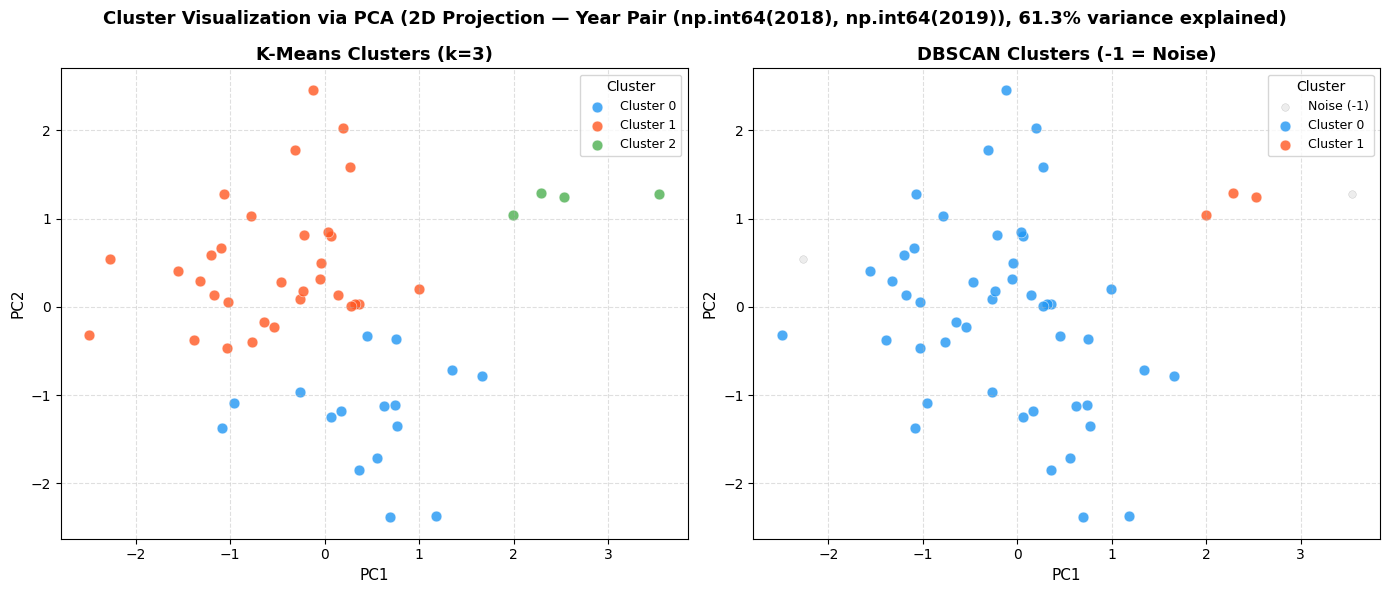

Year Pair (np.int64(2019), np.int64(2019)): missing DBSCAN results. Skipping plot.


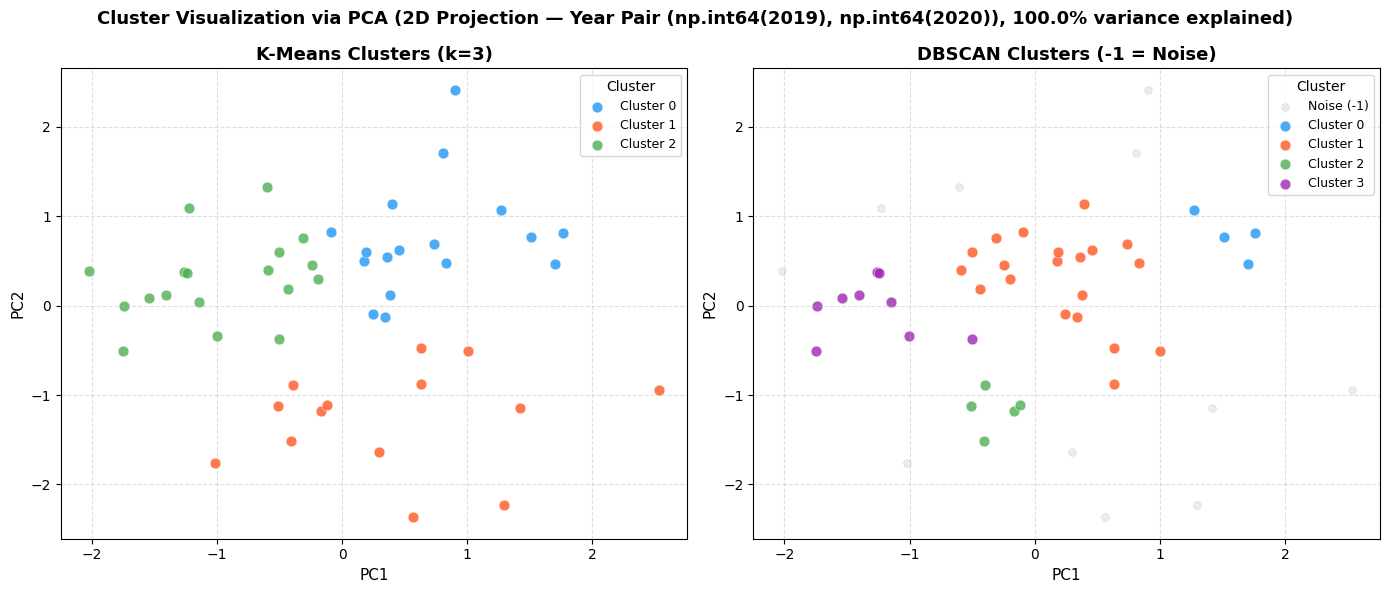

Year Pair (np.int64(2019), np.int64(2021)): Not enough valid data for PCA visualization (shape: (52, 1)). Skipping plot.
Year Pair (np.int64(2020), np.int64(2020)): missing DBSCAN results. Skipping plot.


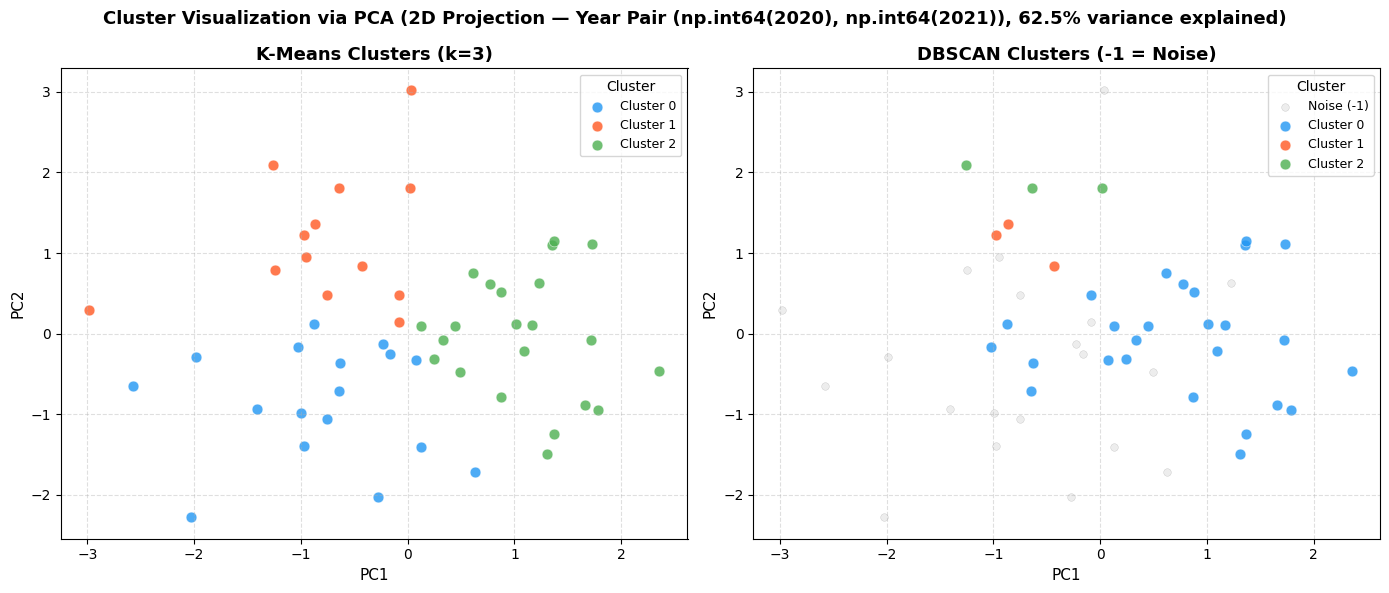

Year Pair (np.int64(2021), np.int64(2021)): missing DBSCAN results. Skipping plot.


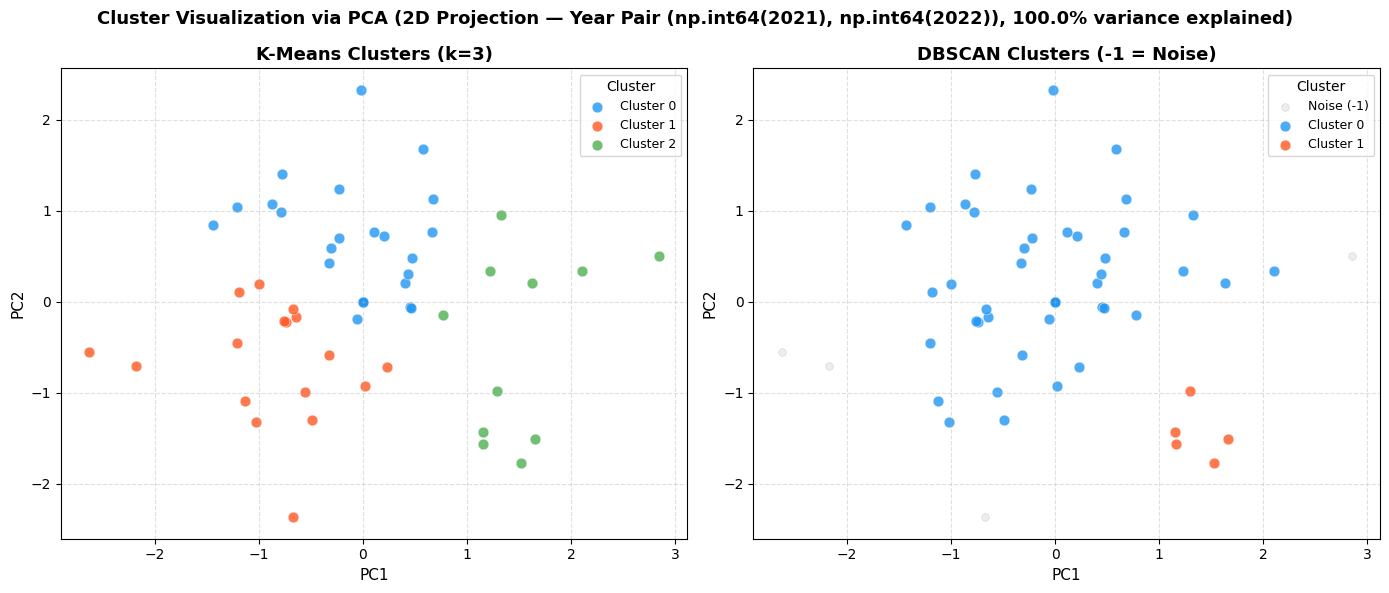

Year Pair (np.int64(2022), np.int64(2022)): missing DBSCAN results. Skipping plot.


In [ ]:
for year_pair, km_labels in all_kmeans_labels.items():
    yr_start_val, yr_end_val = year_pair

    # Get the original data subset for this year_pair
    current_df = clean_df[
        (clean_df['yr_start'] == yr_start_val) &
        (clean_df['yr_end'] == yr_end_val)
    ].copy()

    # Get indicator columns and drop any that are all NaN for this specific group
    current_X_data = current_df.filter(like='__').dropna(axis=1)

    # Ensure enough samples and features for PCA for visualization
    if current_X_data.empty or current_X_data.shape[0] < 2 or current_X_data.shape[1] < 2:
        print(f"Year Pair {year_pair}: Not enough valid data for PCA visualization (shape: {current_X_data.shape}). Skipping plot.")
        continue

    # Scale the data for this year pair before PCA
    scaler_vis = StandardScaler()
    X_scaled_vis = scaler_vis.fit_transform(current_X_data)

    # Perform PCA locally for visualization for this year pair
    pca_vis = PCA(n_components=2, random_state=42)
    X_pca = pca_vis.fit_transform(X_scaled_vis)
    explained_var = pca_vis.explained_variance_ratio_.sum()

    # Retrieve DBSCAN labels for this year pair
    db_labels = all_dbscan_labels.get(year_pair)

    # Skip if DBSCAN results are missing for this year pair
    if db_labels is None:
        print(f"Year Pair {year_pair}: missing DBSCAN results. Skipping plot.")
        continue

    best_k = all_best_k.get(year_pair, None)

    # Check for 'total_score_risk_level' in current_df to plot ground truth
    if 'total_score_risk_level' in current_df.columns:
        risk_labels = current_df['total_score_risk_level'].reset_index(drop=True).values
        plot_ground_truth = True
    else:
        plot_ground_truth = False

    n_panels = 3 if plot_ground_truth else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(20 if plot_ground_truth else 14, 6))

    if n_panels == 2:
        axes = np.array(axes) # ensure axes is an array for consistent indexing

    # --- Panel 1: K-Means clusters ---
    km_unique = np.unique(km_labels)
    km_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
                  '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

    for i, label in enumerate(km_unique):
        mask = km_labels == label
        color = km_palette[i % len(km_palette)]
        axes[0].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=color, label=f'Cluster {label}',
            alpha=0.8, s=60, edgecolors='white', linewidths=0.4
        )

    axes[0].set_title(f'K-Means Clusters (k={best_k})', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('PC1', fontsize=11)
    axes[0].set_ylabel('PC2', fontsize=11)
    axes[0].legend(title='Cluster', fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # --- Panel 2: DBSCAN clusters ---
    db_unique = np.unique(db_labels)
    db_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
                  '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

    for label in db_unique:
        mask = db_labels == label
        if label == -1:
            axes[1].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c='lightgray', label='Noise (-1)',
                alpha=0.4, s=30, edgecolors='gray', linewidths=0.3
            )
        else:
            color = db_palette[int(label) % len(db_palette)]
            axes[1].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f'Cluster {label}',
                alpha=0.8, s=60, edgecolors='white', linewidths=0.4
            )

    axes[1].set_title('DBSCAN Clusters (-1 = Noise)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('PC1', fontsize=11)
    axes[1].set_ylabel('PC2', fontsize=11)
    axes[1].legend(title='Cluster', fontsize=9)
    axes[1].grid(True, linestyle='--', alpha=0.4)

    # --- Panel 3: Ground truth risk label ---
    if plot_ground_truth:
        risk_palette = {0: '#8BC34A', 1: '#FFC107', 2: '#D32F2F'} # Updated palette for 3 risk levels
        risk_names = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}

        for val in np.unique(risk_labels):
            mask = risk_labels == val
            axes[2].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c=risk_palette.get(val, '#777777'),
                label=risk_names.get(val, f'Class {val}'),
                alpha=0.8, s=60, edgecolors='white', linewidths=0.4
            )

        axes[2].set_title('Ground Truth: Total Score Risk Level', fontsize=13, fontweight='bold')
        axes[2].set_xlabel('PC1', fontsize=11)
        axes[2].set_ylabel('PC2', fontsize=11)
        axes[2].legend(title='Risk Level', fontsize=9)
        axes[2].grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(
        f'Cluster Visualization via PCA (2D Projection — Year Pair {year_pair}, {explained_var:.1%} variance explained)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


--- Cluster Profiles for Year Pair (np.int64(2018), np.int64(2019)) ---


km_cluster,0,1,2
oral__dentist_visit_child_1_17,84.506,85.734,57.75
oral__prev_dental_child_1_17,35.281,52.562,50.30
sleep__short_sleep_child_4m_14y,38.975,29.966,43.50
npaw__pa_guideline_6_13,26.550,30.003,31.25
alc__alcohol_hs,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN


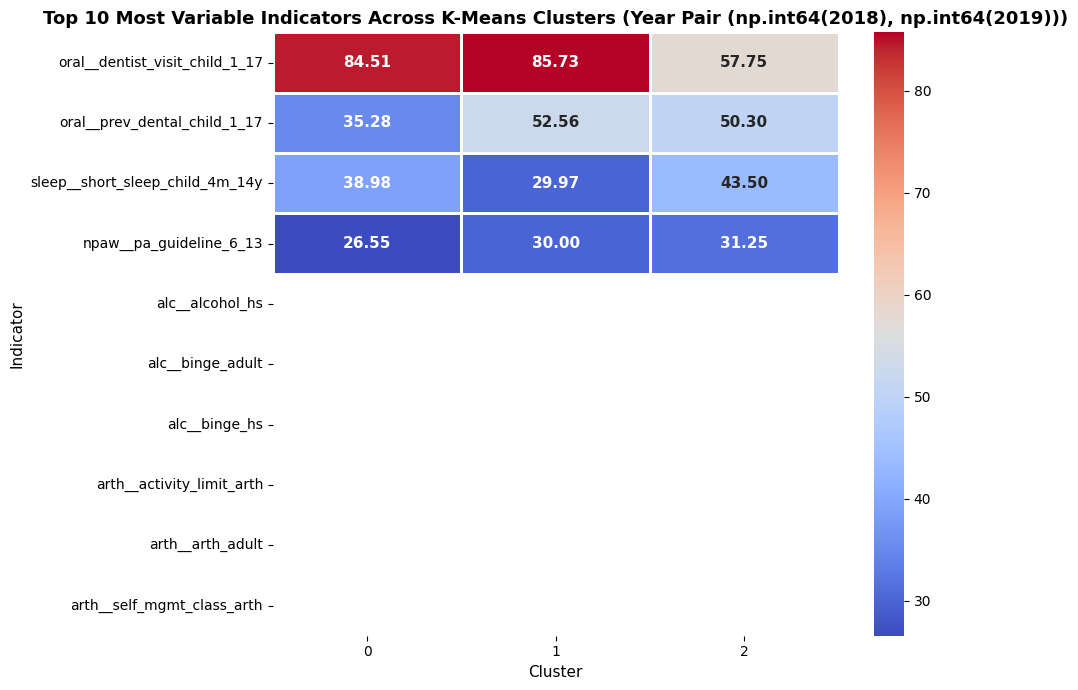


--- Cluster Profiles for Year Pair (np.int64(2019), np.int64(2019)) ---


km_cluster,0,1,2
copd__smoking_copd_adult,44.870,34.040,30.726
arth__severe_joint_pain_arth,42.335,30.301,29.158
cvd__med_hbp_adult,75.345,69.436,60.853
sdoh__ins_after_preg_recent_birth,77.323,82.401,91.628
dis__any_disability_adult,34.655,32.107,23.116
npaw__breastfed_12m,30.589,38.373,41.932
hs__chronic2plus_adult,25.720,14.465,20.421
npaw__no_leisure_pa_adult,33.190,26.635,22.689
npaw__obesity_adult,35.275,35.100,26.037
imm__flu_vax_risk_18_64,39.740,39.603,48.537


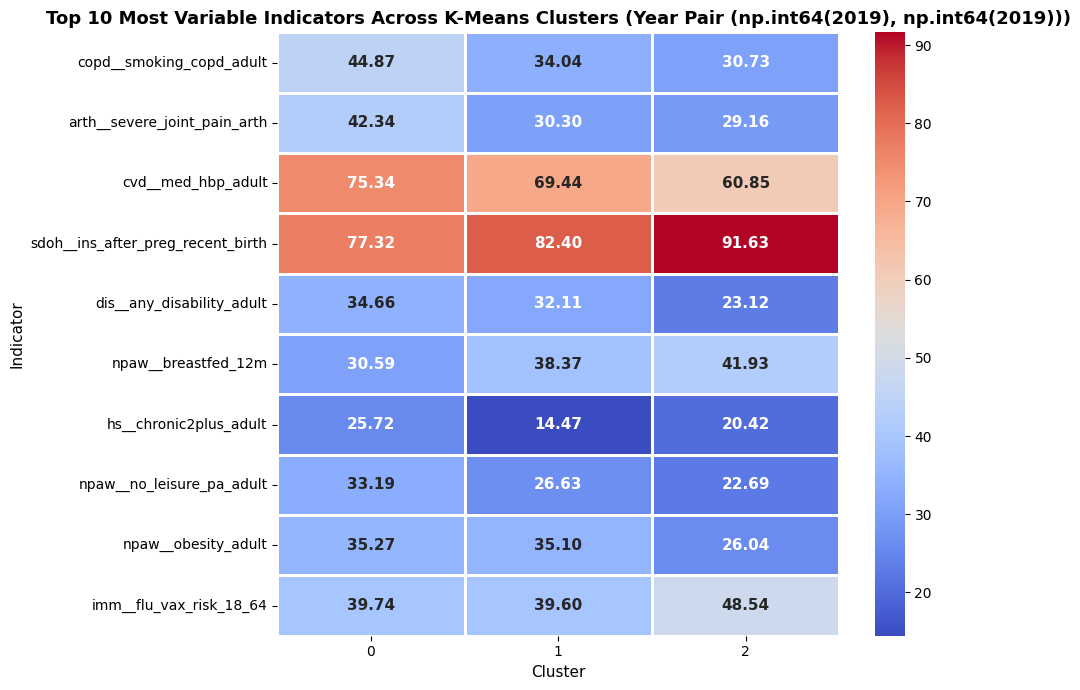


--- Cluster Profiles for Year Pair (np.int64(2019), np.int64(2020)) ---


km_cluster,0,1,2
cog__scd_discussed_hcp_45plus,47.112,38.221,53.594
cog__scd_45plus,12.235,8.243,8.528
cog__caregiver_dementia_adult,25.900,22.000,24.429
cog__caregiver_friend_family_adult,22.467,20.775,20.800
alc__alcohol_hs,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN


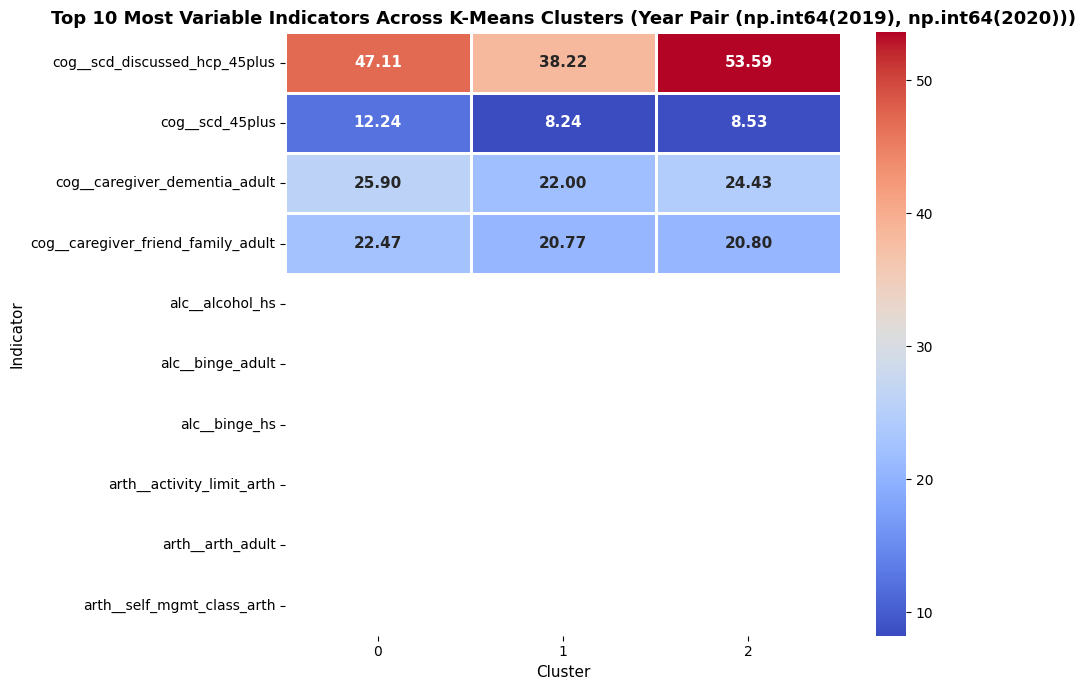


--- Cluster Profiles for Year Pair (np.int64(2019), np.int64(2021)) ---


km_cluster,0,1,2
sdoh__food_insecure_household,10.359,13.811,7.979
alc__alcohol_hs,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN
arth__inactive_arth,NaN,NaN,NaN
arth__pa_counsel_arth,NaN,NaN,NaN
arth__severe_joint_pain_arth,NaN,NaN,NaN


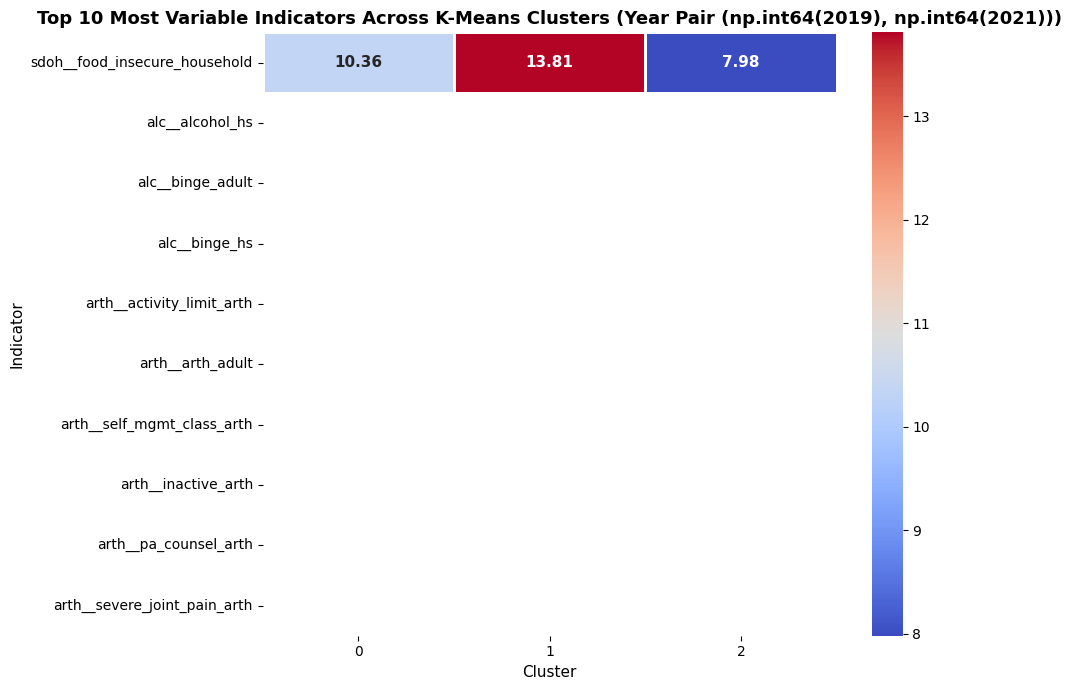


--- Cluster Profiles for Year Pair (np.int64(2020), np.int64(2020)) ---


km_cluster,0,1,2
oral__prev_dental_pre_preg_recent_birth,48.92,33.288,34.637
sdoh__ins_before_preg_recent_birth,96.37,82.902,82.519
imm__flu_vax_adult,49.84,37.964,51.181
oral__teeth_lost_6plus_65plus,26.40,39.755,32.686
oral__no_teeth_lost_18_64,73.54,62.145,62.668
hs__chronic2plus_adult,18.27,23.823,11.298
imm__flu_vax_risk_18_64,55.75,44.959,44.992
npaw__breastfed_12m,44.58,34.309,37.710
npaw__obesity_adult,26.74,36.314,34.977
oral__dentist_visit_past_year_adult,68.81,59.327,65.947


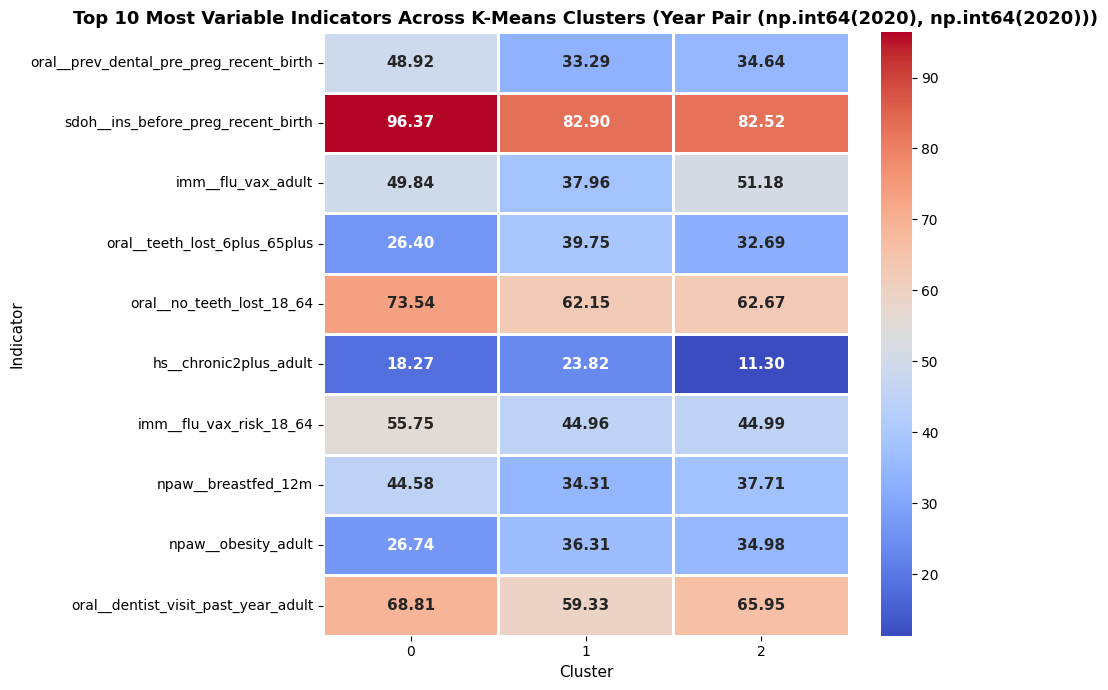


--- Cluster Profiles for Year Pair (np.int64(2020), np.int64(2021)) ---


km_cluster,0,1,2
oral__prev_dental_child_1_17,38.906,55.223,44.150
npaw__pa_guideline_6_13,21.106,16.608,29.545
sleep__short_sleep_child_4m_14y,41.359,38.415,29.932
oral__dentist_visit_child_1_17,71.394,81.962,80.768
alc__alcohol_hs,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN


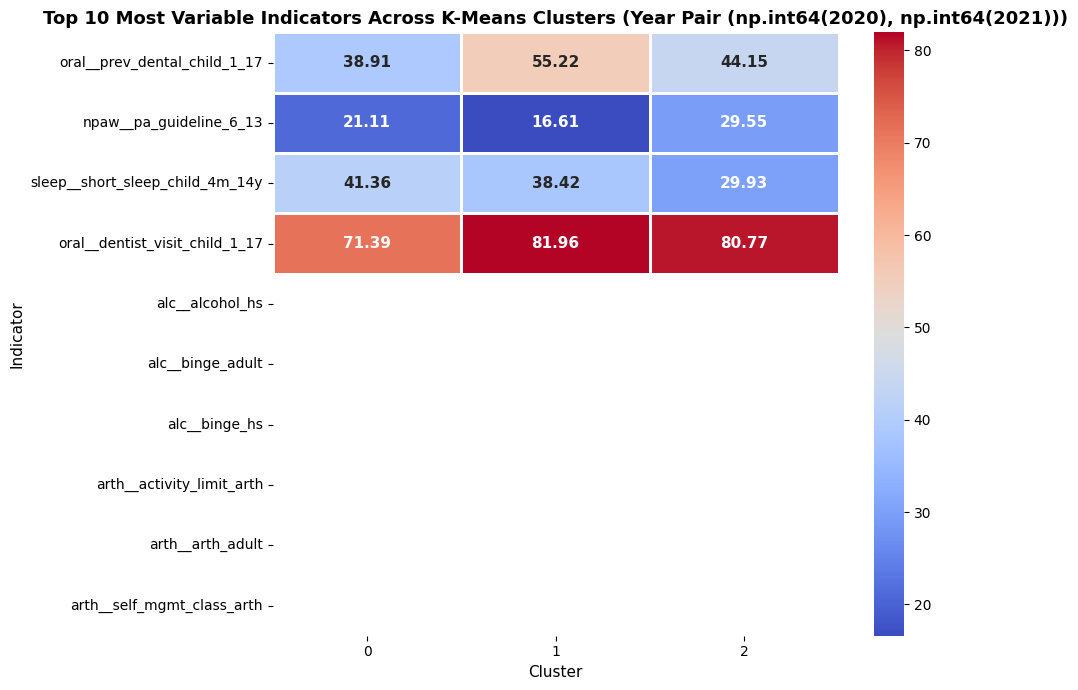


--- Cluster Profiles for Year Pair (np.int64(2021), np.int64(2021)) ---


km_cluster,0,1,2
cvd__high_chol_screened_adult,32.386,36.531,50.350
imm__pneumo_vax_65plus,71.520,65.972,53.212
imm__flu_vax_risk_18_64,43.006,46.424,30.675
imm__flu_vax_adult,46.544,45.128,32.450
sdoh__poverty_lt150_all,23.833,19.504,33.462
cvd__hbp_adult,33.854,29.355,42.375
arth__severe_joint_pain_arth,33.800,28.959,40.512
hs__chronic2plus_adult,24.322,17.021,28.112
hs__fair_poor_health_adult,15.302,14.821,24.800
sdoh__ins_after_preg_recent_birth,89.908,92.235,81.660


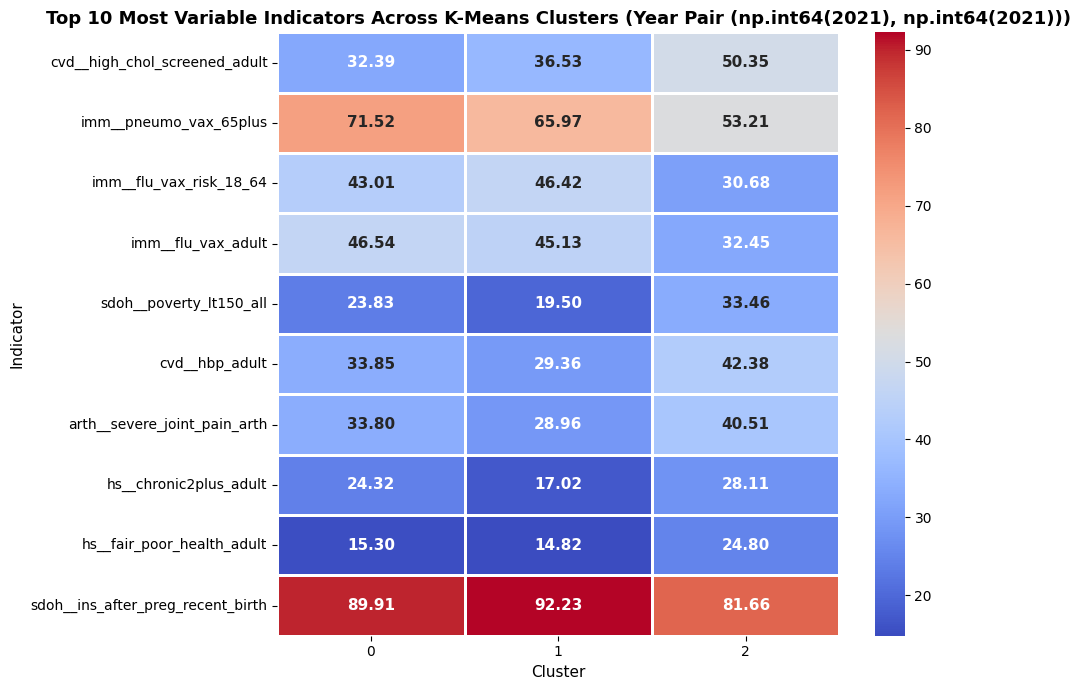


--- Cluster Profiles for Year Pair (np.int64(2021), np.int64(2022)) ---


km_cluster,0,1,2
cog__caregiver_friend_family_adult,21.406,13.306,23.100
cog__caregiver_dementia_adult,26.106,24.500,18.082
cog__scd_discussed_hcp_45plus,41.900,43.538,46.380
cog__scd_45plus,12.635,11.338,11.680
alc__alcohol_hs,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN


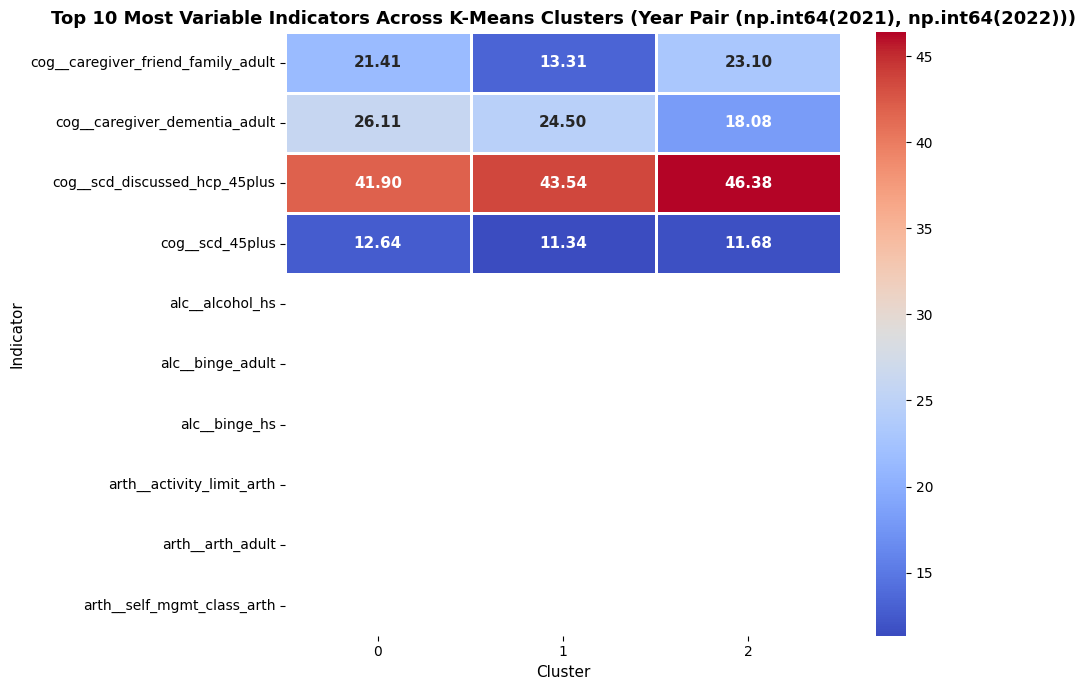


--- Cluster Profiles for Year Pair (np.int64(2022), np.int64(2022)) ---


km_cluster,0,1,2
imm__flu_vax_risk_18_64,36.709,50.052,42.451
oral__no_teeth_lost_18_64,55.964,68.443,65.939
oral__teeth_lost_6plus_65plus,40.727,27.900,34.226
imm__pneumo_vax_risk_18_64,30.136,35.329,24.276
imm__flu_vax_adult,41.709,51.114,42.478
npaw__no_leisure_pa_adult,30.127,20.376,25.261
dm__diabetes_adult,21.564,13.600,12.830
oral__dentist_visit_past_year_adult,54.991,63.214,62.191
hs__fair_poor_health_adult,25.373,18.071,18.687
arth__arth_adult,23.464,26.595,31.443


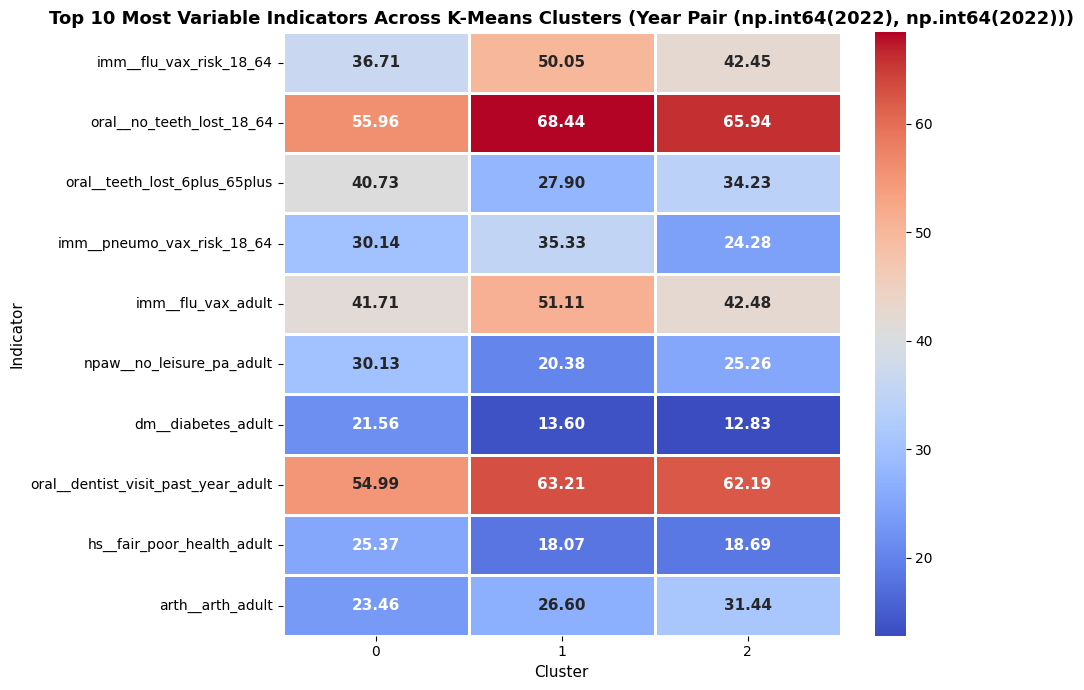

In [ ]:
for year_pair, km_labels_for_pair in all_kmeans_labels.items():
    yr_start_val, yr_end_val = year_pair

    # Get the original data subset for this year_pair to extract indicator values
    current_df_subset = clean_df[(clean_df['yr_start'] == yr_start_val) & (clean_df['yr_end'] == yr_end_val)].copy()

    # Ensure indicator_cols is defined for the profiling. It was defined earlier globally.
    # If 'indicator_cols' is not global, it needs to be derived here:
    # indicator_cols = [col for col in current_df_subset.columns if '__' in col]

    profile_df_loop = current_df_subset.filter(like='__').reset_index(drop=True)
    profile_df_loop['km_cluster'] = km_labels_for_pair

    cluster_profiles_loop = profile_df_loop.groupby('km_cluster').mean().T

    # Only consider indicators that exist in this specific subset after dropping NaNs for PCA
    # The previous PCA step might have dropped some columns due to too many NaNs in a specific year_pair
    # So, we should only consider columns that are present in `profile_df_loop`
    indicator_cols_present = [col for col in profile_df_loop.columns if '__' in col]

    # Calculate std only for present indicator columns
    top_varied_loop = cluster_profiles_loop.loc[indicator_cols_present].std(axis=1).sort_values(ascending=False).head(10).index

    print(f"\n--- Cluster Profiles for Year Pair {year_pair} ---")
    display(cluster_profiles_loop.loc[top_varied_loop].round(3))

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cluster_profiles_loop.loc[top_varied_loop],
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=0.8,
        linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    plt.title(f'Top 10 Most Variable Indicators Across K-Means Clusters (Year Pair {year_pair})',
              fontsize=13, fontweight='bold')
    plt.xlabel('Cluster', fontsize=11)
    plt.ylabel('Indicator', fontsize=11)
    plt.tight_layout()
    plt.show()

# Unsupervised Clustering (for alltime aggregated)
### Methods: K-Means and DBSCAN
Clustering is applied to the full scaled feature matrix to identify natural groupings of state observations based on chronic disease and behavioral profiles; independent of the risk labels. Internal validation uses Silhouette Score and Davies-Bouldin Index. Clusters are visualized via PCA 2D projection and profiled by their top indicator patterns.
###K-mean clustering compared to risk score groups.

### K-Means Clustering
The Elbow Method and Silhouette Score are used to select the optimal number of clusters k, then the final model is fit and evaluated.

Running K-Means for All-Time Aggregated Data:


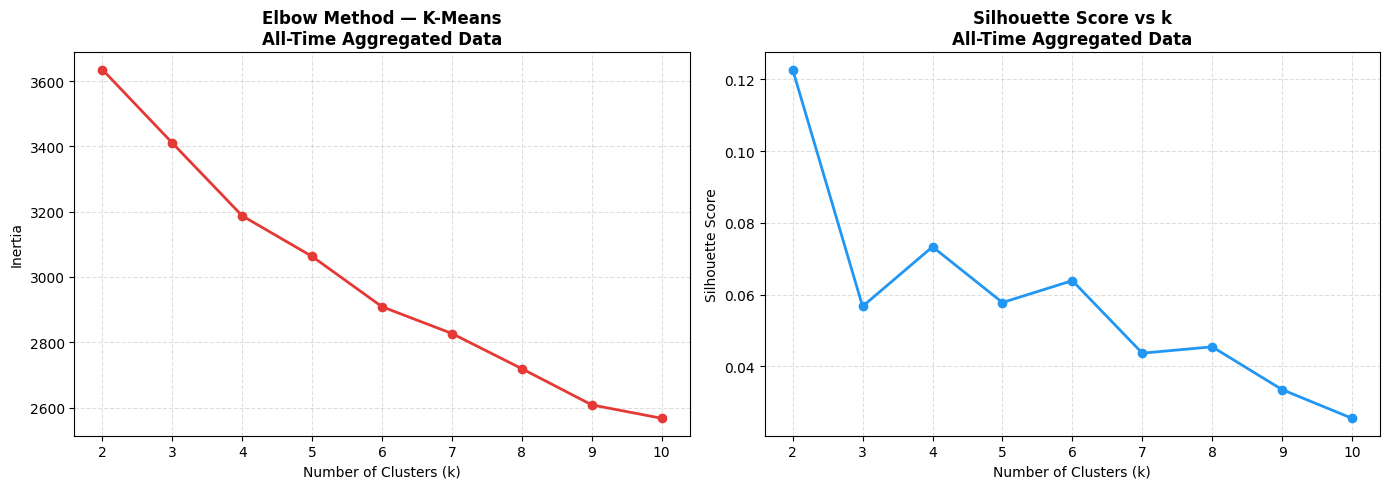

All-Time Aggregated Data | Optimal k: 2
K-Means | Silhouette: 0.1227 | Davies-Bouldin: 2.3410
------------------------------------------------------------


In [ ]:
# Initialize lists to store clustering metrics for the aggregated dataset
inertias = []
sil_scores = []

print("Running K-Means for All-Time Aggregated Data:")

X_all = X_scaled # Use the PCA result from the aggregated data
n_samples = X_all.shape[0]

# Need at least 3 samples for clustering with k >= 2
if n_samples < 3:
    print(f"Not enough samples for clustering (n={n_samples}). Skipping.")
else:
    # Adaptive k range
    max_k = min(10, n_samples - 1)
    if max_k < 2:
        print(f"max_k < 2. Skipping K-Means.")
    else:
        k_range = range(2, max_k + 1)

        # Compute clustering metrics across k
        for k in k_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(X_all)

            inertias.append(km.inertia_)

            # silhouette requires at least 2 clusters and fewer clusters than samples
            if len(np.unique(labels)) > 1 and len(np.unique(labels)) < n_samples:
                sil_scores.append(silhouette_score(X_all, labels))
            else:
                sil_scores.append(np.nan)

        # Plot for the aggregated data
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(k_range, inertias, marker='o', color='#E53935', linewidth=2)
        axes[0].set_title('Elbow Method — K-Means\nAll-Time Aggregated Data', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].grid(True, linestyle='--', alpha=0.4)

        axes[1].plot(k_range, sil_scores, marker='o', color='#2196F3', linewidth=2)
        axes[1].set_title('Silhouette Score vs k\nAll-Time Aggregated Data', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Silhouette Score')
        axes[1].grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

        # Choose best k based on silhouette
        valid_sil = [s for s in sil_scores if not np.isnan(s)]
        if len(valid_sil) == 0:
            print(f"No valid silhouette scores. Skipping final K-Means.")
        else:
            best_idx = int(np.nanargmax(sil_scores))
            best_k = list(k_range)[best_idx]

            # Final KMeans for this aggregated data
            km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
            km_labels = km_final.fit_predict(X_all)

            km_sil = silhouette_score(X_all, km_labels)
            km_db = davies_bouldin_score(X_all, km_labels)

            all_kmeans_labels = km_labels # Store as a single variable now
            all_kmeans_models = km_final # Store as a single variable now
            all_best_k = best_k # Store as a single variable now
            all_kmeans_metrics = { # Store as a single variable now
                'best_k': best_k,
                'silhouette': km_sil,
                'davies_bouldin': km_db
            }

            print(f"All-Time Aggregated Data | Optimal k: {best_k}")
            print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
            print("-" * 60)

In [ ]:
# Manually set the number of clusters (K)
# Please provide your desired K value when prompted, or set it directly here.
manual_k = 3 # Placeholder. You will be prompted to enter this value.

# Fallback if running non-interactively or if no input is given
if manual_k is None:
    try:
        manual_k = int(input("Enter your desired K value for K-Means clustering (e.g., 3, 5, 7): "))
    except ValueError:
        print("Invalid input. Using default K=5.")
        manual_k = 5


print(f"Running K-Means with a manual K value of {manual_k} for All-Time Aggregated Data:")

X_all = X_scaled
n_samples = X_all.shape[0]

if n_samples < manual_k:
    print(f"Not enough samples ({n_samples}) for K-Means with K={manual_k}. Skipping.")
elif manual_k < 2:
    print(f"K must be at least 2 for K-Means. Skipping.")
else:
    # Perform K-Means clustering with the manual K value
    km_final = KMeans(n_clusters=manual_k, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    # Evaluate the clustering
    km_sil = silhouette_score(X_all, km_labels)
    km_db = davies_bouldin_score(X_all, km_labels)

    # Store results using the requested variable names
    all_kmeans_labels = km_labels
    all_best_k = manual_k # Storing the manual K as 'all_best_k' as requested
    all_kmeans_models = km_final
    all_kmeans_metrics = {
        'best_k': manual_k,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"All-Time Aggregated Data | Manual K: {manual_k}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)


Running K-Means with a manual K value of 3 for All-Time Aggregated Data:
All-Time Aggregated Data | Manual K: 3
K-Means | Silhouette: 0.0567 | Davies-Bouldin: 2.9282
------------------------------------------------------------


Distribution of total_score_risk_level within each K-Means cluster:


total_score_risk_level,0,1,2
km_cluster,,,
0,0.000000,0.083333,0.916667
1,0.100000,0.800000,0.100000
2,0.521739,0.434783,0.043478


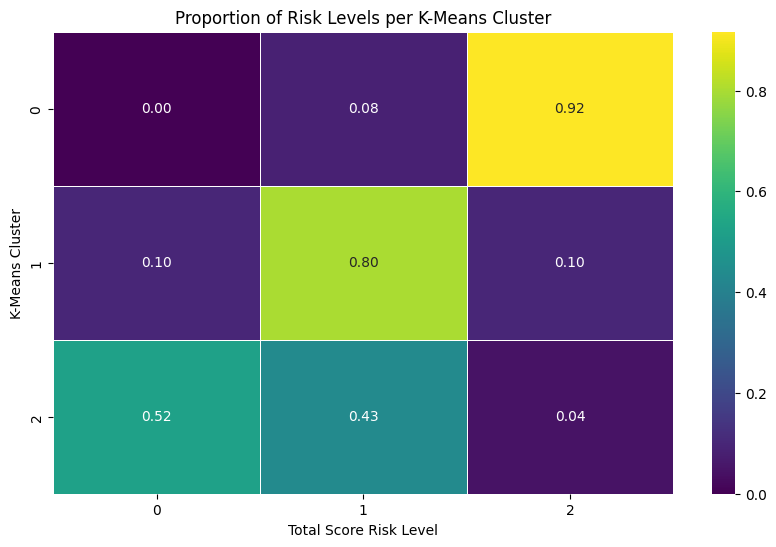


Mean total_score_risk_level for each K-Means cluster:


,total_score_risk_level
km_cluster,
0,1.916667
1,1.000000
2,0.521739


In [ ]:
# Create a DataFrame to compare K-Means labels with total_score_risk_level
comparison_df = clean_df_alltime_final[['state_name', 'total_score_risk_level']].copy()
comparison_df['km_cluster'] = all_kmeans_labels

# Display the count of each risk level within each cluster
print("Distribution of total_score_risk_level within each K-Means cluster:")
cluster_risk_distribution = comparison_df.groupby('km_cluster')['total_score_risk_level'].value_counts(normalize=True).unstack(fill_value=0)
display(cluster_risk_distribution)

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_risk_distribution, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Proportion of Risk Levels per K-Means Cluster')
plt.xlabel('Total Score Risk Level')
plt.ylabel('K-Means Cluster')
plt.show()

# Optionally, display the mean risk level for each cluster
print("\nMean total_score_risk_level for each K-Means cluster:")
mean_risk_per_cluster = comparison_df.groupby('km_cluster')['total_score_risk_level'].mean()
display(mean_risk_per_cluster)


### DBSCAN Clustering
DBSCAN identifies clusters of arbitrary shape and marks low-density observations as noise (label = −1). Epsilon and min_samples are tuned via a parameter sweep maximizing silhouette score.

In [ ]:
# Store results as single variables now, not dictionaries
# all_dbscan_params = {}
# all_dbscan_labels = {}
# all_dbscan_metrics = {}

print("Running DBSCAN for All-Time Aggregated Data:")

X_all = X_scaled
n_samples = X_all.shape[0]

if n_samples < 5:
    print(f"Not enough samples for DBSCAN (n={n_samples}). Skipping.")
else:
    best_sil_db = -1
    best_eps = None
    best_min_samp = None
    best_labels = None

    # Parameter grid (can be tuned further)
    eps_values = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5]
    min_samples_values = [3, 5, 7, 10]

    for eps, min_s in product(eps_values, min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_all)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Need at least 2 clusters for silhouette
        if n_clusters >= 2:
            try:
                sil = silhouette_score(X_all, labels)
                if sil > best_sil_db:
                    best_sil_db = sil
                    best_eps = eps
                    best_min_samp = min_s
                    best_labels = labels
            except:
                continue

    # If no valid clustering found
    if best_labels is None:
        print(f"No valid DBSCAN clustering found.")
    else:
        # Final model with best params
        db_final = DBSCAN(eps=best_eps, min_samples=best_min_samp)
        db_labels = db_final.fit_predict(X_all)

        n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise_db = list(db_labels).count(-1)

        print(f"All-Time Aggregated Data | Best eps={best_eps}, min_samples={best_min_samp}")
        print(f"DBSCAN clusters: {n_clusters_db} | Noise points: {n_noise_db}")

        # Evaluate only non-noise points
        non_noise = db_labels != -1

        if non_noise.sum() > 0 and len(set(db_labels[non_noise])) >= 2:
            db_sil = silhouette_score(X_all[non_noise], db_labels[non_noise])
            db_db = davies_bouldin_score(X_all[non_noise], db_labels[non_noise])

            print(f"DBSCAN | Silhouette: {db_sil:.4f} | Davies-Bouldin: {db_db:.4f}")

            all_dbscan_metrics = {
                'eps': best_eps,
                'min_samples': best_min_samp,
                'n_clusters': n_clusters_db,
                'noise_points': n_noise_db,
                'silhouette': db_sil,
                'davies_bouldin': db_db
            }
        else:
            print("DBSCAN: insufficient clusters for evaluation.")
            all_dbscan_metrics = {
                'eps': best_eps,
                'min_samples': best_min_samp,
                'n_clusters': n_clusters_db,
                'noise_points': n_noise_db,
                'silhouette': None,
                'davies_bouldin': None
            }

        all_dbscan_labels = db_labels # Store as a single variable now
        all_dbscan_params = (best_eps, best_min_samp) # Store as a single variable now

        print("-" * 60)

        # ┅ Optional: Visualization
        plt.figure(figsize=(7, 5))
        plt.scatter(X_all[:, 0], X_all[:, 1], c=db_labels, cmap='tab10', s=70, edgecolor='k')
        plt.title(f'DBSCAN Clusters (PCA)\nAll-Time Aggregated Data',
                  fontsize=12, fontweight='bold')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.show()

Running DBSCAN for All-Time Aggregated Data:
No valid DBSCAN clustering found.


### Cluster Visualization & Profiling
Observations are projected onto 2 principal components and colored by cluster. K-Means clusters are then profiled by the top indicators that vary most across groups.

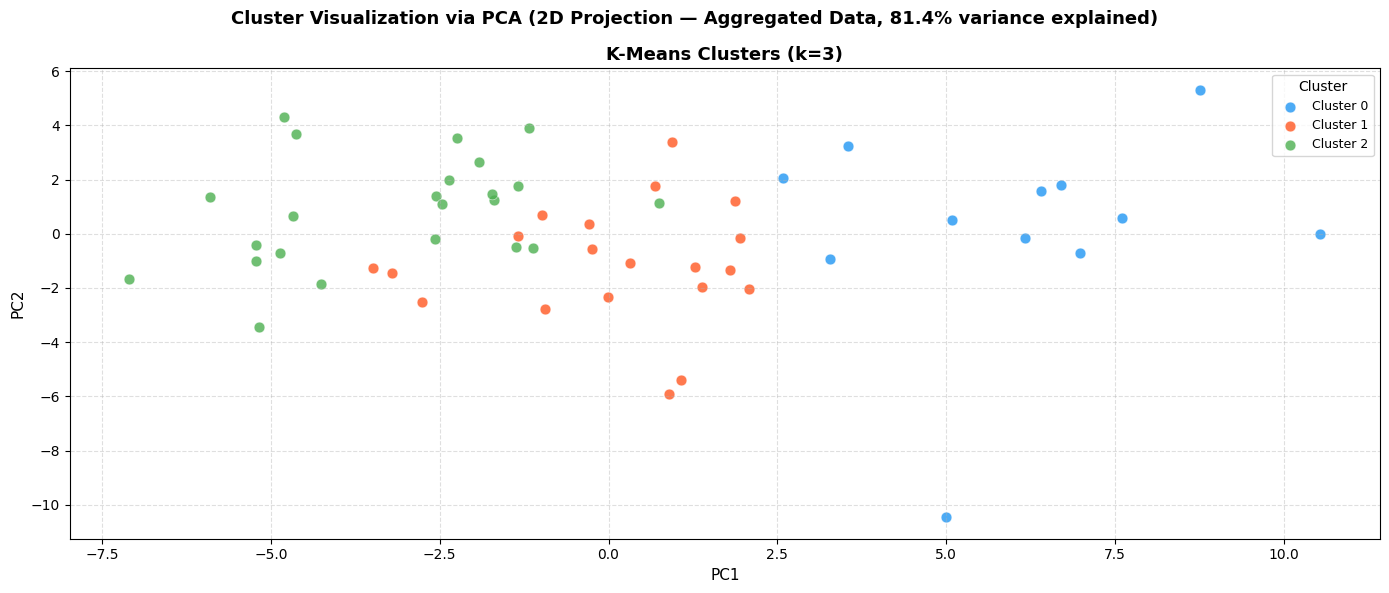

In [ ]:
# Access the global variables for the aggregated data
# X_pca, km_labels, db_labels, all_best_k, explained_variance_pca are now single variables
# from the previous cells operating on clean_df_alltime_processed

km_labels = all_kmeans_labels
#db_labels = all_dbscan_labels
best_k = 3
explained_var = explained_variance_pca

# For aggregated data, we don't have 'yr_start', 'yr_end', or 'risk_label' in the same context
# as the time-series clean_df. So, ground truth plotting is removed.
plot_ground_truth = False

n_panels = 1 # Only K-Means and DBSCAN plots
fig, axes = plt.subplots(1, n_panels, figsize=(14, 6))

# --- Panel 1: K-Means clusters ---
km_unique = np.unique(km_labels)
km_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
              '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

for i, label in enumerate(km_unique):
    mask = km_labels == label
    color = km_palette[i % len(km_palette)]
    axes.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=f'Cluster {label}',
        alpha=0.8, s=60, edgecolors='white', linewidths=0.4
    )

axes.set_title(f'K-Means Clusters (k={best_k})', fontsize=13, fontweight='bold')
axes.set_xlabel('PC1', fontsize=11)
axes.set_ylabel('PC2', fontsize=11)
axes.legend(title='Cluster', fontsize=9)
axes.grid(True, linestyle='--', alpha=0.4)


plt.suptitle(
    f'Cluster Visualization via PCA (2D Projection — Aggregated Data, {explained_var:.1%} variance explained)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

km_cluster,0,1,2
arth__severe_joint_pain_arth,41.604,35.460,27.233
oral__teeth_lost_6plus_65plus,42.708,32.860,29.828
npaw__breastfed_12m,29.917,35.083,42.828
sdoh__ins_after_preg_recent_birth,79.473,89.627,89.408
cvd__hbp_adult,40.646,32.455,29.678
copd__smoking_copd_adult,43.039,35.206,32.354
sleep__short_sleep_child_4m_14y,40.899,36.443,30.150
oral__no_teeth_lost_18_64,58.292,63.476,69.030
cvd__med_high_chol_adult,41.062,36.588,30.703
npaw__pa_guideline_adult,45.842,49.996,56.055


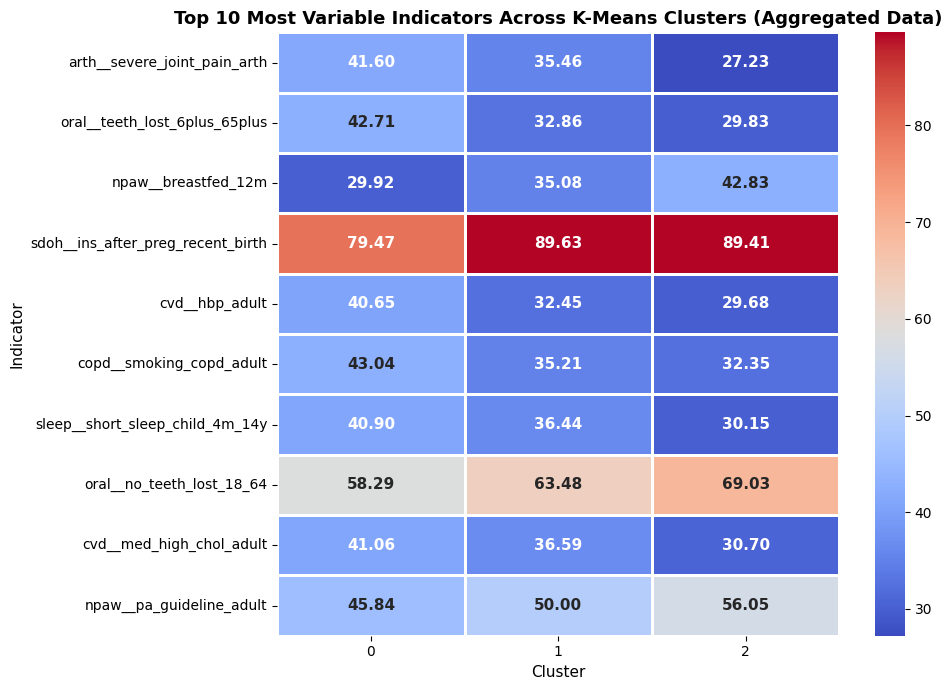

In [ ]:
profile_df = X.reset_index(drop=True).copy()
profile_df['km_cluster'] = all_kmeans_labels

cluster_profiles = profile_df.groupby('km_cluster').mean().T

top_varied = cluster_profiles.std(axis=1).sort_values(ascending=False).head(10).index
display(cluster_profiles.loc[top_varied].round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(
    cluster_profiles.loc[top_varied],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Top 10 Most Variable Indicators Across K-Means Clusters (Aggregated Data)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Indicator', fontsize=11)
plt.tight_layout()
plt.show()